# 08 — Análise comparativa do threshold de similaridade

Este notebook **só lê os resultados** de `run_similarity_threshold.py`: não carrega
modelos, não gera reflexões e não refaz bootstrap. A análise foi organizada para
comparar `compact`, `simple`, `diagnostic` e `complex` sob o limite de **uma memória**.

Além das curvas individuais, os painéis abaixo respondem quatro perguntas:

1. Em que similaridade surge um benefício estável?
2. O corte aprendido generaliza para o holdout e supera o placebo?
3. O ganho vem de corrigir mais respostas do que estragar respostas corretas?
4. Algum estilo parece melhor apenas porque suas gerações foram truncadas?


In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "rmcq").is_dir():
        ROOT = candidate
        sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Não encontrei a raiz do repositório contendo rmcq/")

RESULTS_ROOT = ROOT / "data" / "results" / "similarity_threshold_v2"
EXPERIMENT_ID = os.environ.get("RMCQ_THRESHOLD_EXPERIMENT_ID") or None
COMPARISON_POOLS = ["all", "errors"]
SAVE_FIGURES = True

REQUIRED = [
    "manifest.json",
    "analysis/all_outcomes.csv",
    "analysis/thresholds_calibration.csv",
    "analysis/effect_curves_calibration.csv",
    "analysis/heldout_policies.csv",
]


def is_complete(path):
    return all((path / relative).exists() for relative in REQUIRED)


if EXPERIMENT_ID:
    OUT_DIR = RESULTS_ROOT / EXPERIMENT_ID
    if not is_complete(OUT_DIR):
        missing = [x for x in REQUIRED if not (OUT_DIR / x).exists()]
        raise FileNotFoundError(f"Execução {EXPERIMENT_ID} incompleta; faltam: {missing}")
else:
    candidates = [p for p in RESULTS_ROOT.iterdir() if p.is_dir() and is_complete(p)]
    if not candidates:
        raise FileNotFoundError("Nenhuma execução concluída foi encontrada.")
    OUT_DIR = max(candidates, key=lambda p: (p / "analysis/heldout_policies.csv").stat().st_mtime)
    EXPERIMENT_ID = OUT_DIR.name

# Diretório novo: não sobrescreve os plots da análise anterior.
PLOT_DIR = OUT_DIR / "plots_comparison_v2"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
manifest = json.loads((OUT_DIR / "manifest.json").read_text(encoding="utf-8"))

preferred_depths = ["compact", "simple", "diagnostic", "complex"]
available_depths = list(manifest.get("depths", []))
DEPTH_ORDER = [d for d in preferred_depths if d in available_depths]
DEPTH_ORDER += [d for d in available_depths if d not in DEPTH_ORDER]
MODELS = list(manifest["models"])
DATASETS = list(manifest["datasets"])
DEPTH_COLORS = dict(zip(DEPTH_ORDER, plt.cm.viridis(np.linspace(0.12, 0.88, len(DEPTH_ORDER)))))

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2})


def finish(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(PLOT_DIR / filename, dpi=190, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def short_path(path):
    try:
        return path.relative_to(ROOT)
    except ValueError:
        return path


print("experiment_id:", EXPERIMENT_ID)
print("diretório:", short_path(OUT_DIR))
print("modelos:", MODELS)
print("datasets:", DATASETS)
print("reflexões:", DEPTH_ORDER)


experiment_id: 3f47a5b014cd
diretório: data/results/similarity_threshold_v2/3f47a5b014cd
modelos: ['phi4-mini', 'mistral-7b']
datasets: ['aqua', 'arc', 'logiqa2', 'openbookqa']
reflexões: ['compact', 'simple', 'diagnostic', 'complex']


In [2]:
results_df = pd.read_csv(OUT_DIR / "analysis" / "all_outcomes.csv")
threshold_df = pd.read_csv(OUT_DIR / "analysis" / "thresholds_calibration.csv")
curves_df = pd.read_csv(OUT_DIR / "analysis" / "effect_curves_calibration.csv")
policy_df = pd.read_csv(OUT_DIR / "analysis" / "heldout_policies.csv")

optional = {}
for name, relative in {
    "transitions": "analysis/decision_transitions.csv",
    "dedup": "retrieval/dedup_audit.csv",
    "truncation": "retrieval/embedding_truncation.csv",
    "pairs": "retrieval/pairs.csv",
}.items():
    path = OUT_DIR / relative
    optional[name] = pd.read_csv(path) if path.exists() else pd.DataFrame()

print(f"{len(results_df):,} resultados individuais")
print(f"{len(threshold_df):,} estimativas de threshold")
print(f"{len(policy_df):,} avaliações holdout")
display(threshold_df.groupby(["depth", "pool"], dropna=False)["threshold"].agg(["count", "median"]))


100,084 resultados individuais
96 estimativas de threshold
174 avaliações holdout


/tmp/ipykernel_4180821/2981920022.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  results_df = pd.read_csv(OUT_DIR / "analysis" / "all_outcomes.csv")


count    median
depth      pool                    
compact    all          4  0.737892
           correct      2  0.640968
           errors       4  0.545096
complex    all          3  0.401493
           correct      4  0.454676
           errors       4  0.430372
diagnostic all          5  0.727946
           correct      3  0.405677
           errors       4  0.299953
simple     all          5  0.818896
           correct      4  0.582580
           errors       4  0.550486

## 1. Qualidade operacional das reflexões

O gráfico não tenta julgar semanticamente a reflexão. Ele verifica um confundidor
importante em modelos pequenos: tamanho da saída e término por limite de tokens.
Uma variante muito truncada não está sendo comparada em condições equivalentes.


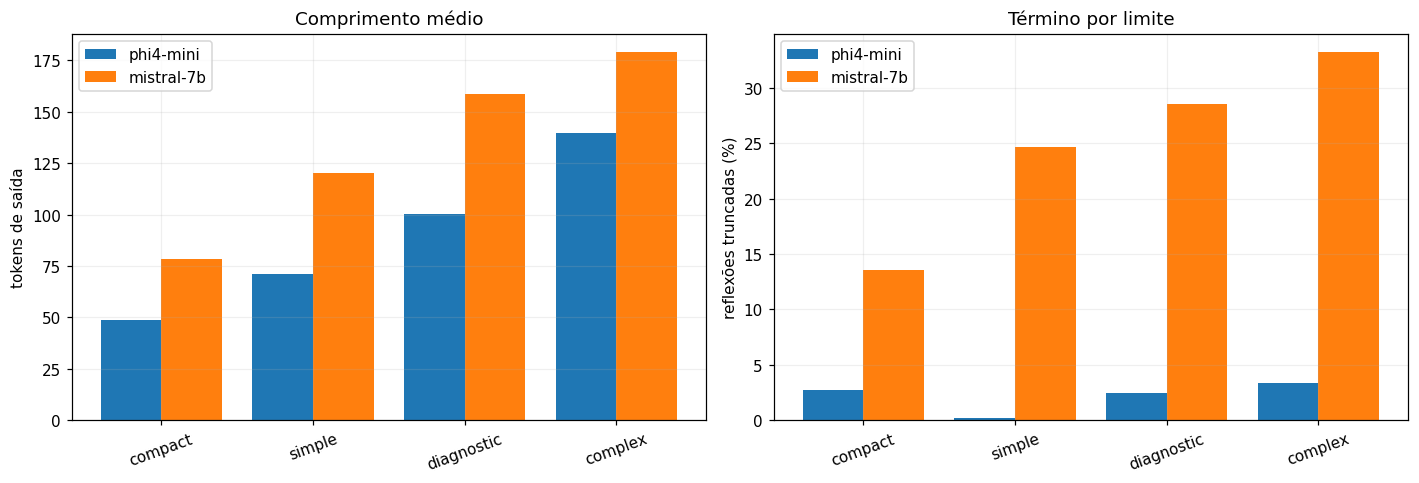

,model,depth,n,mean_words,mean_tokens,truncation_rate
4,mistral-7b,compact,9228,56.820004,78.601214,0.135782
7,mistral-7b,complex,9228,138.126138,179.052557,0.332358
6,mistral-7b,diagnostic,9228,119.062852,158.760945,0.285327
5,mistral-7b,simple,9228,92.192133,120.019939,0.246857
0,phi4-mini,compact,8556,40.303530,48.937588,0.027349
3,phi4-mini,complex,8556,120.009818,139.772440,0.033310
2,phi4-mini,diagnostic,8556,85.566620,100.162342,0.025012
1,phi4-mini,simple,8556,59.991351,71.081230,0.002338


In [3]:
quality_rows = []
for model in MODELS:
    for depth in DEPTH_ORDER:
        path = OUT_DIR / "generations" / model / f"reflections_{depth}.jsonl"
        if not path.exists():
            continue
        records = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
        if not records:
            continue
        words = [len(str(r.get("text", "")).split()) for r in records]
        tokens = [r.get("completion_tokens", np.nan) for r in records]
        reasons = [str(r.get("finish_reason", "")).lower() for r in records]
        quality_rows.append({
            "model": model, "depth": depth, "n": len(records),
            "mean_words": np.mean(words), "mean_tokens": np.nanmean(tokens),
            "truncation_rate": np.mean([x in {"length", "max_tokens"} for x in reasons]),
        })

quality_df = pd.DataFrame(quality_rows)
if quality_df.empty:
    print("Caches de reflexão não foram encontrados; auditoria ignorada.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    width = 0.8 / max(1, len(MODELS))
    x = np.arange(len(DEPTH_ORDER))
    for i, model in enumerate(MODELS):
        sub = quality_df[quality_df.model == model].set_index("depth").reindex(DEPTH_ORDER)
        offset = (i - (len(MODELS) - 1) / 2) * width
        axes[0].bar(x + offset, sub["mean_tokens"], width, label=model)
        axes[1].bar(x + offset, 100 * sub["truncation_rate"], width, label=model)
    axes[0].set(title="Comprimento médio", ylabel="tokens de saída")
    axes[1].set(title="Término por limite", ylabel="reflexões truncadas (%)")
    for ax in axes:
        ax.set_xticks(x, DEPTH_ORDER, rotation=20)
        ax.legend()
    finish(fig, "01_reflection_generation_audit.png")
    display(quality_df.sort_values(["model", "depth"]))


## 2. Cobertura da recuperação

Essas tabelas mostram duplicatas, truncamento do encoder e a faixa de
similaridades disponível. Um threshold próximo do extremo observado deve ser
interpretado com cautela porque possui pouco suporte empírico.


In [4]:
if not optional["dedup"].empty:
    display(optional["dedup"])
if not optional["truncation"].empty:
    display(optional["truncation"])
if not optional["pairs"].empty:
    retrieval_summary = (
        optional["pairs"].groupby(["dataset", "arm", "level"])["similarity"]
        .agg(["count", "min", "median", "max"]).reset_index()
    )
    display(retrieval_summary)


,dataset,source,train,validation,train_internal_duplicates_removed,validation_internal_duplicates_removed,cross_split_stems_removed_from_train
0,aqua,validation.jsonl,79041,252,15888,0,10
1,arc,validation.jsonl,1116,298,1,0,0
2,logiqa2,validation.jsonl,11394,1551,926,14,217
3,openbookqa,validation.jsonl,4816,499,126,1,12


,dataset,split,n,max_seq_length,n_over_limit,rate_over_limit,p95_tokens,max_tokens
0,aqua,train,79041,256,16,0.000202,105.00,381
1,aqua,validation,252,256,0,0.000000,112.00,165
2,arc,train,1116,256,0,0.000000,101.00,193
3,arc,validation,298,256,0,0.000000,99.15,157
4,logiqa2,train,11394,256,993,0.087151,276.00,511
5,logiqa2,validation,1551,256,160,0.103159,285.00,474
6,openbookqa,train,4816,256,0,0.000000,53.00,101
7,openbookqa,validation,499,256,0,0.000000,58.00,97


,dataset,arm,level,count,min,median,max
0,aqua,placebo,placebo,252,-0.002495,0.145484,0.270420
1,aqua,retrieved,target_0.30,252,0.299987,0.300000,0.300042
2,aqua,retrieved,target_0.50,252,0.486762,0.499997,0.501088
3,aqua,retrieved,target_0.70,252,0.507079,0.699216,0.755273
4,aqua,retrieved,top,252,0.513050,0.769234,1.000000
5,arc,placebo,placebo,298,-0.130304,0.018516,0.124072
6,arc,retrieved,target_0.30,298,0.294265,0.300007,0.306205
7,arc,retrieved,target_0.50,298,0.314263,0.497671,0.549609
8,arc,retrieved,target_0.70,298,0.309608,0.545996,0.784661
9,arc,retrieved,top,298,0.337965,0.590570,0.991845


## 3. Curvas de calibração — quatro reflexões na mesma escala

Cada figura fixa modelo, dataset e origem da memória. Os quatro painéis usam os
mesmos limites, tornando diferenças de formato e estabilidade visíveis. A linha
vertical é o threshold aprendido; a faixa é o IC 95% do efeito pareado.


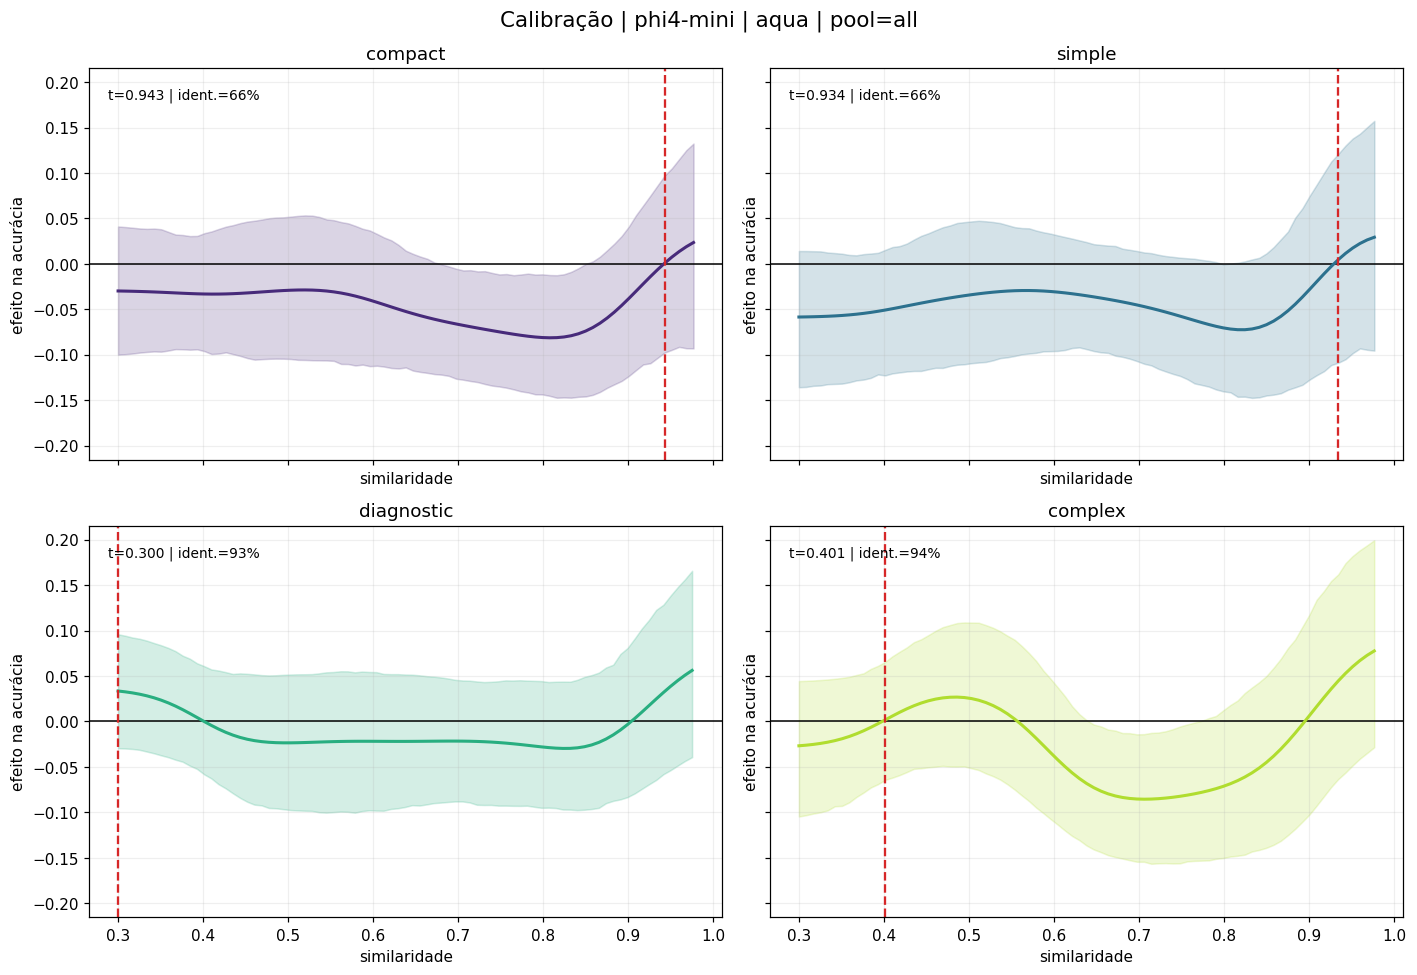

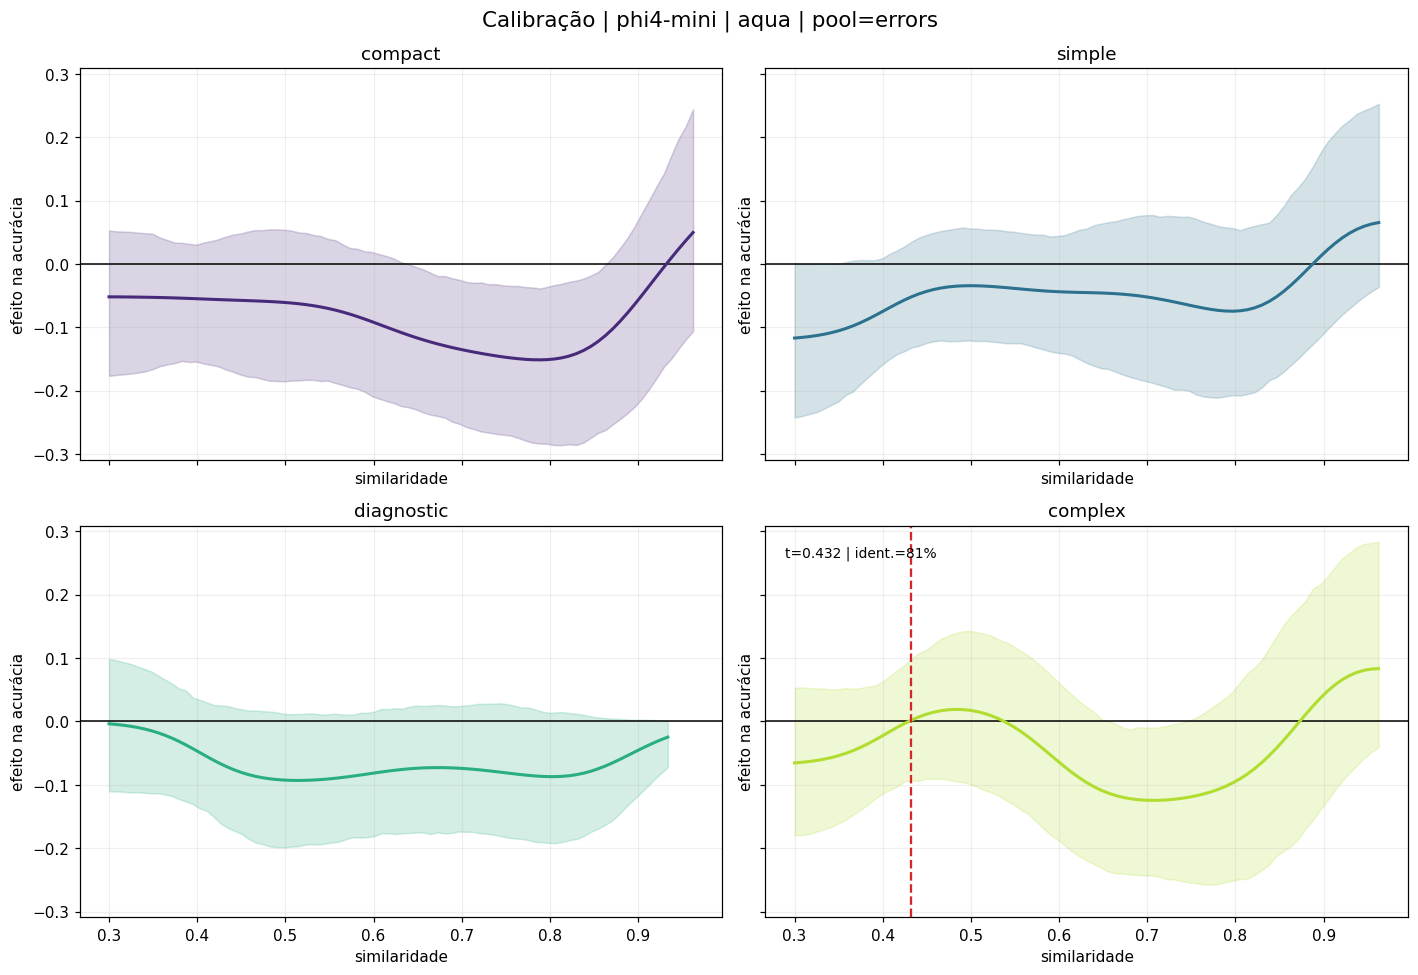

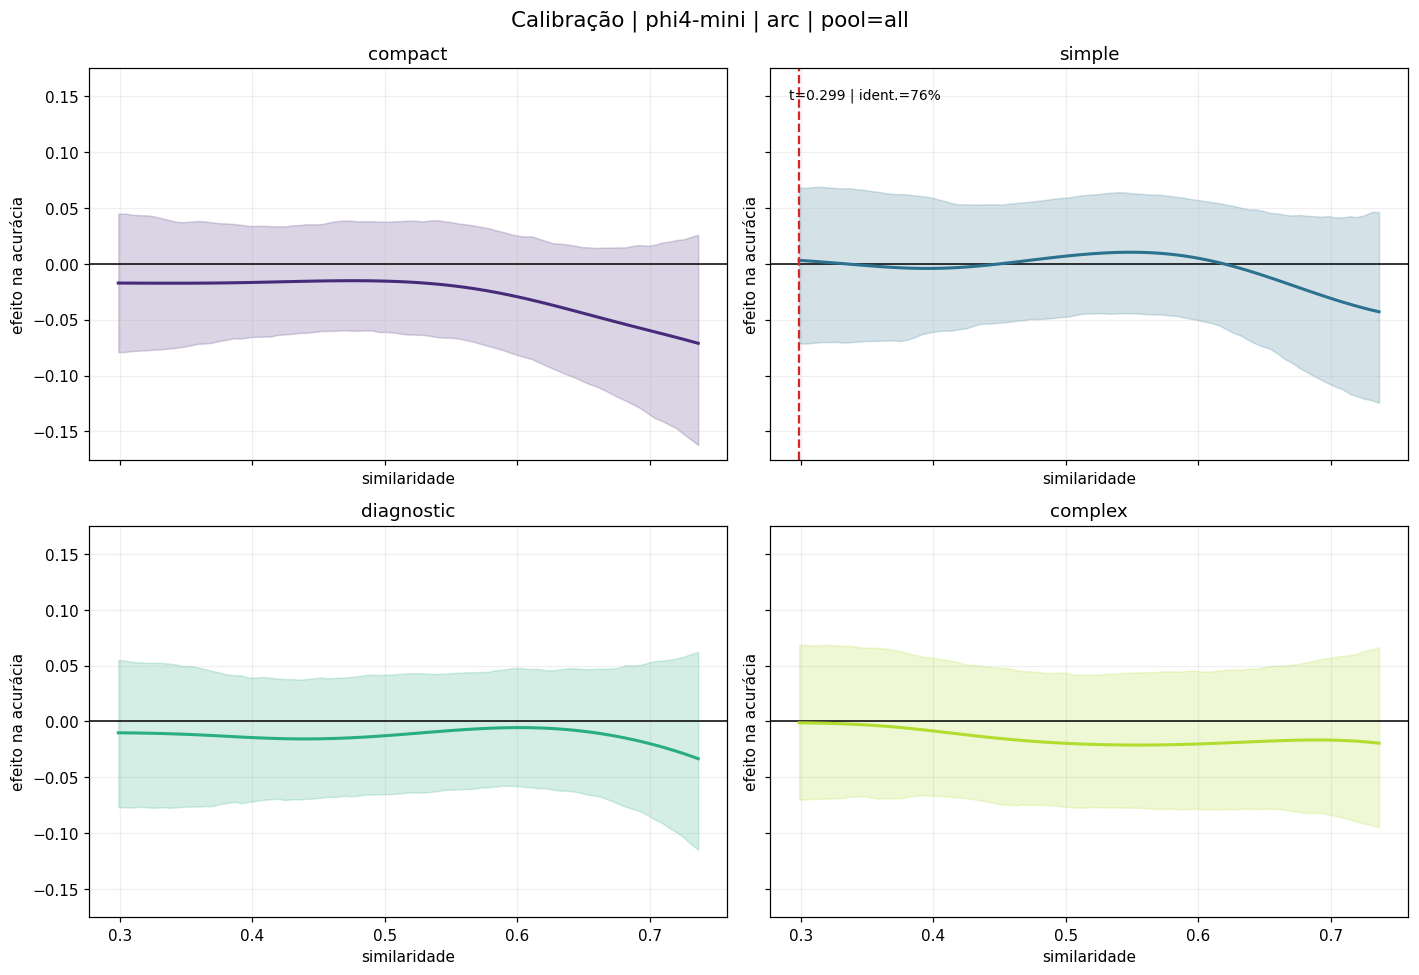

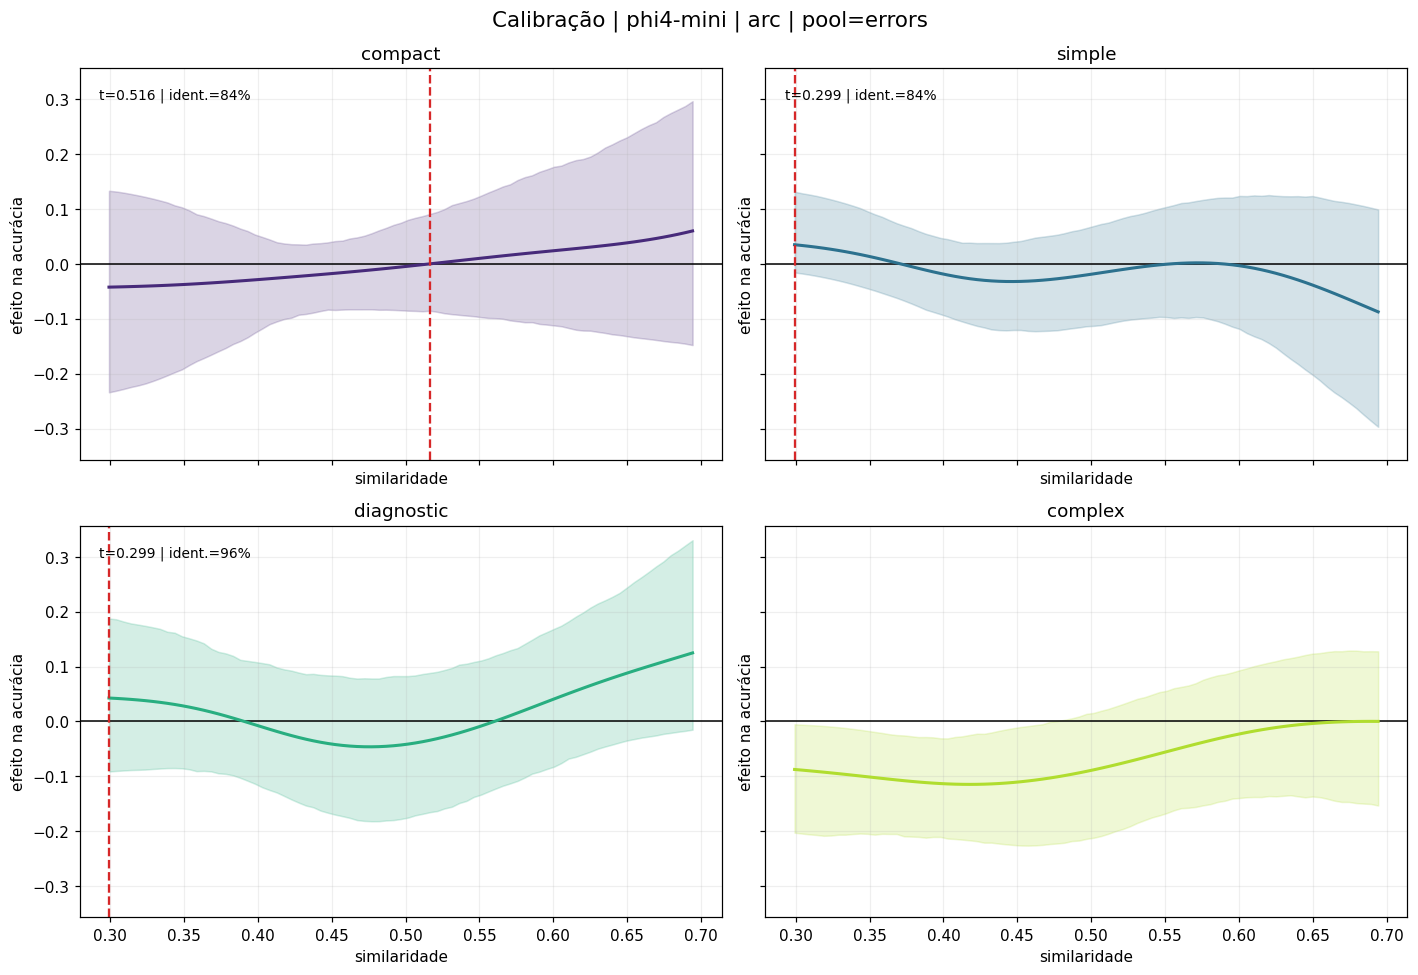

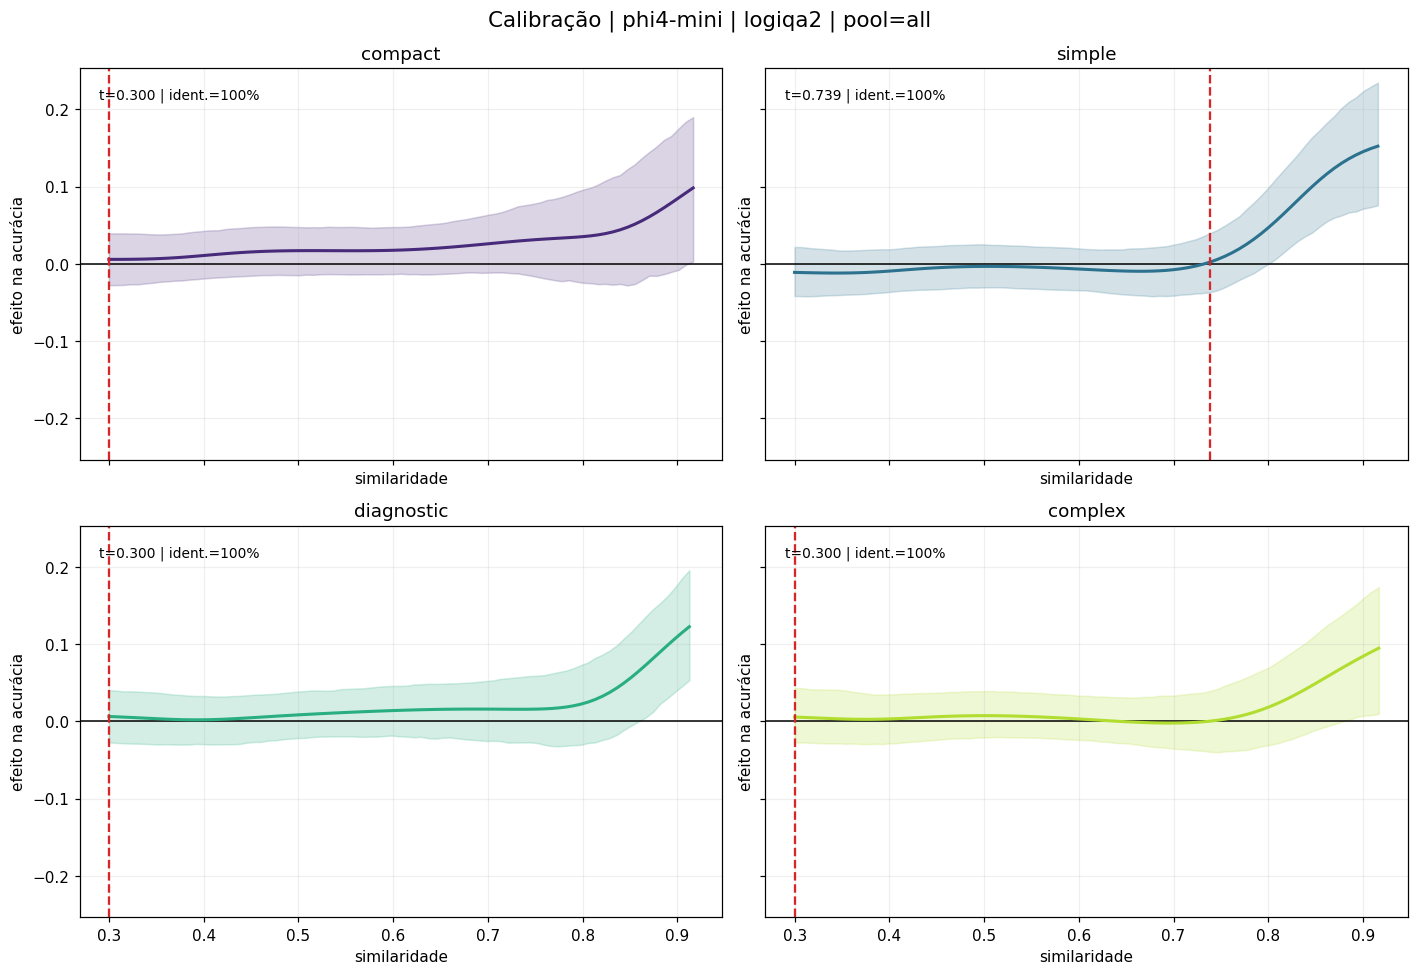

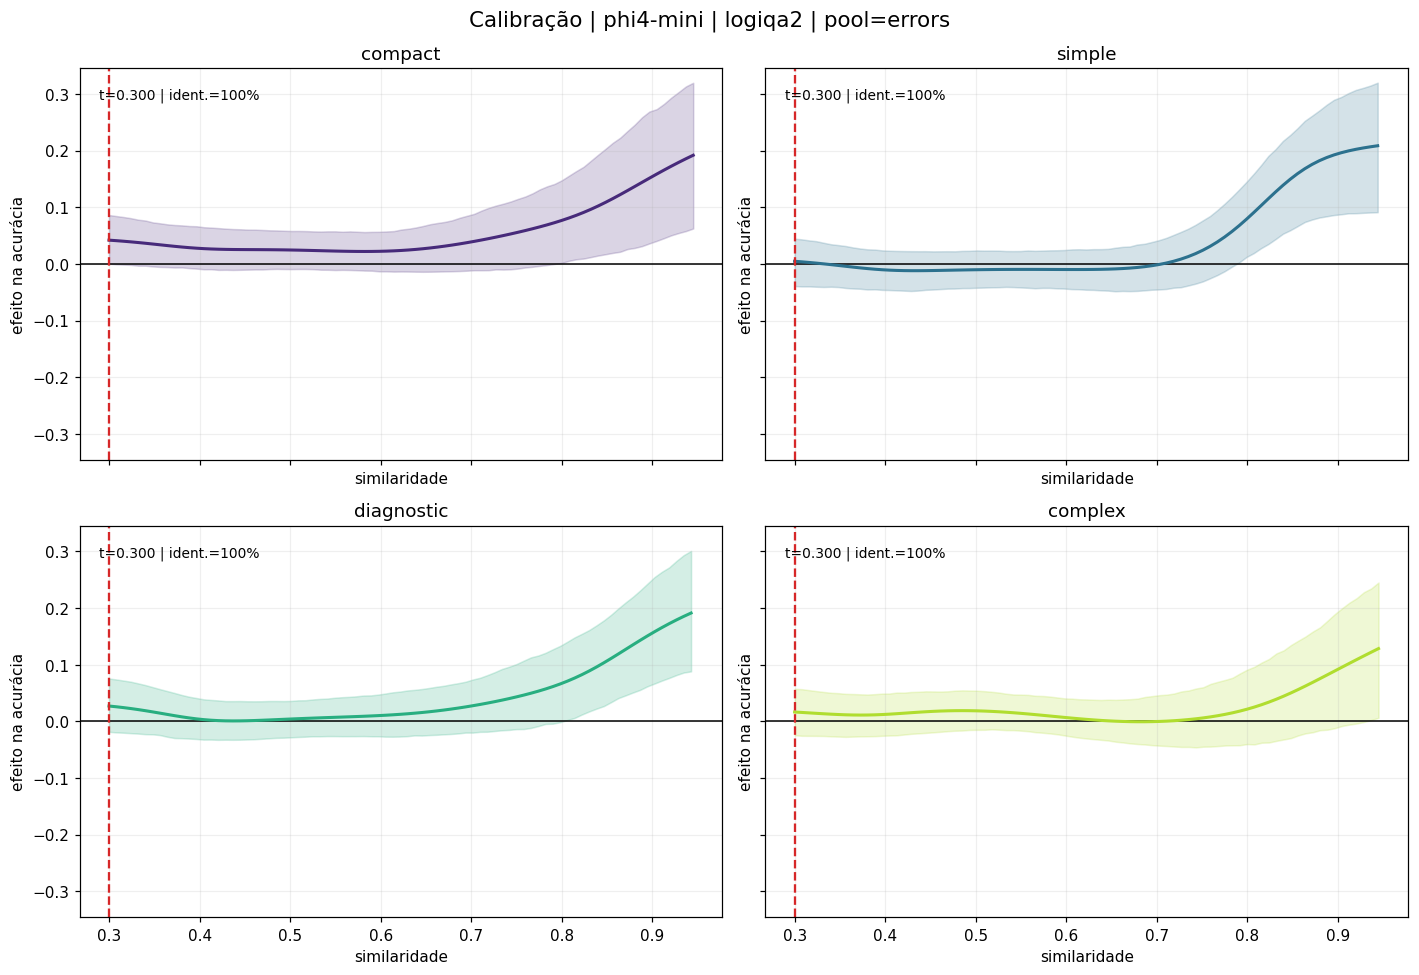

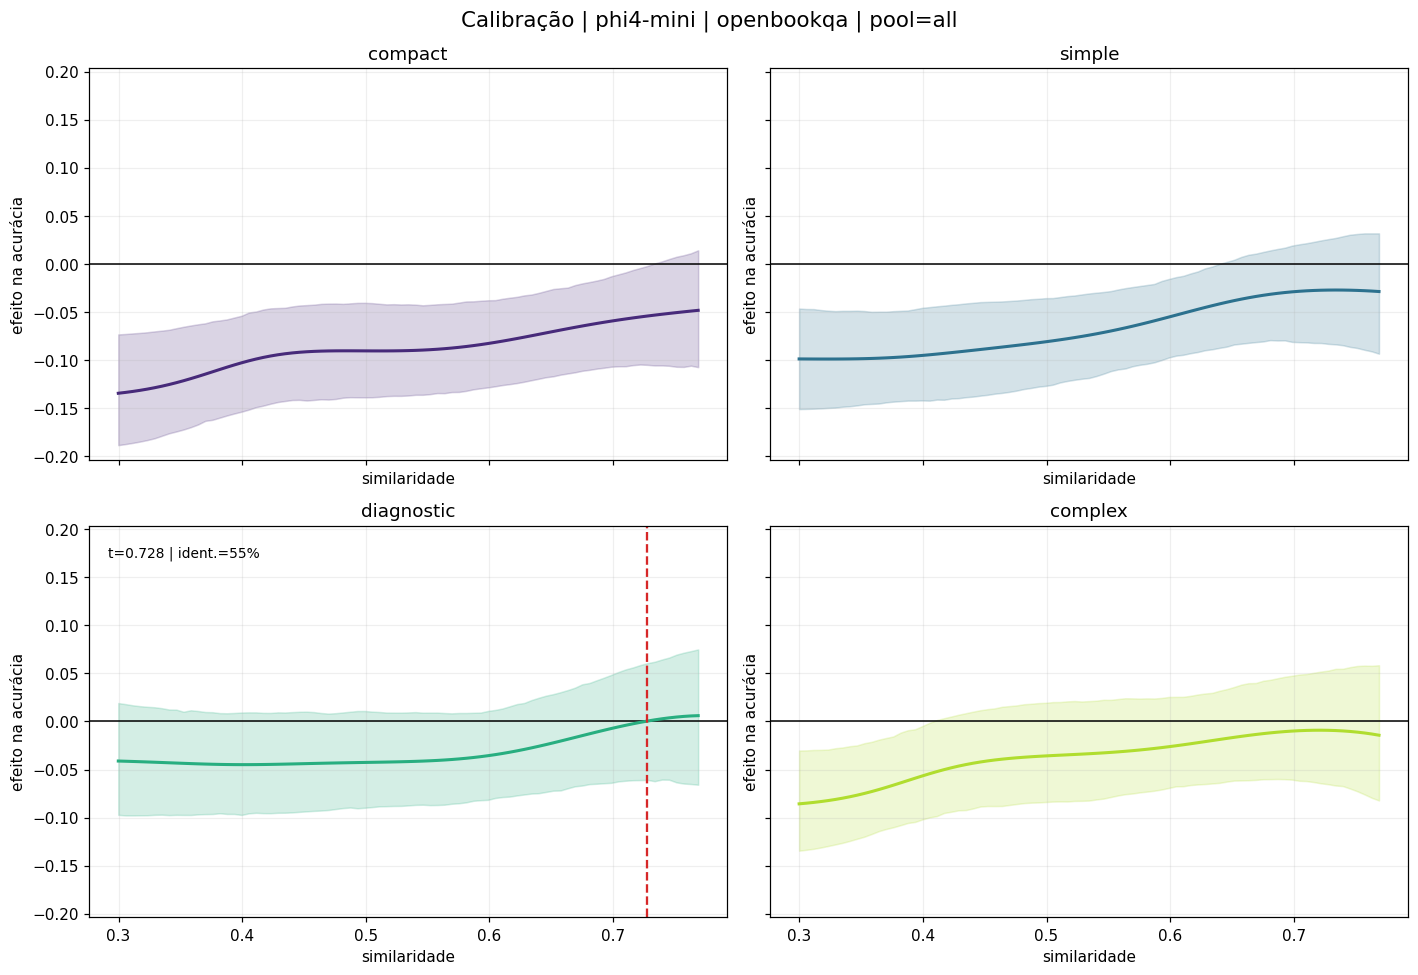

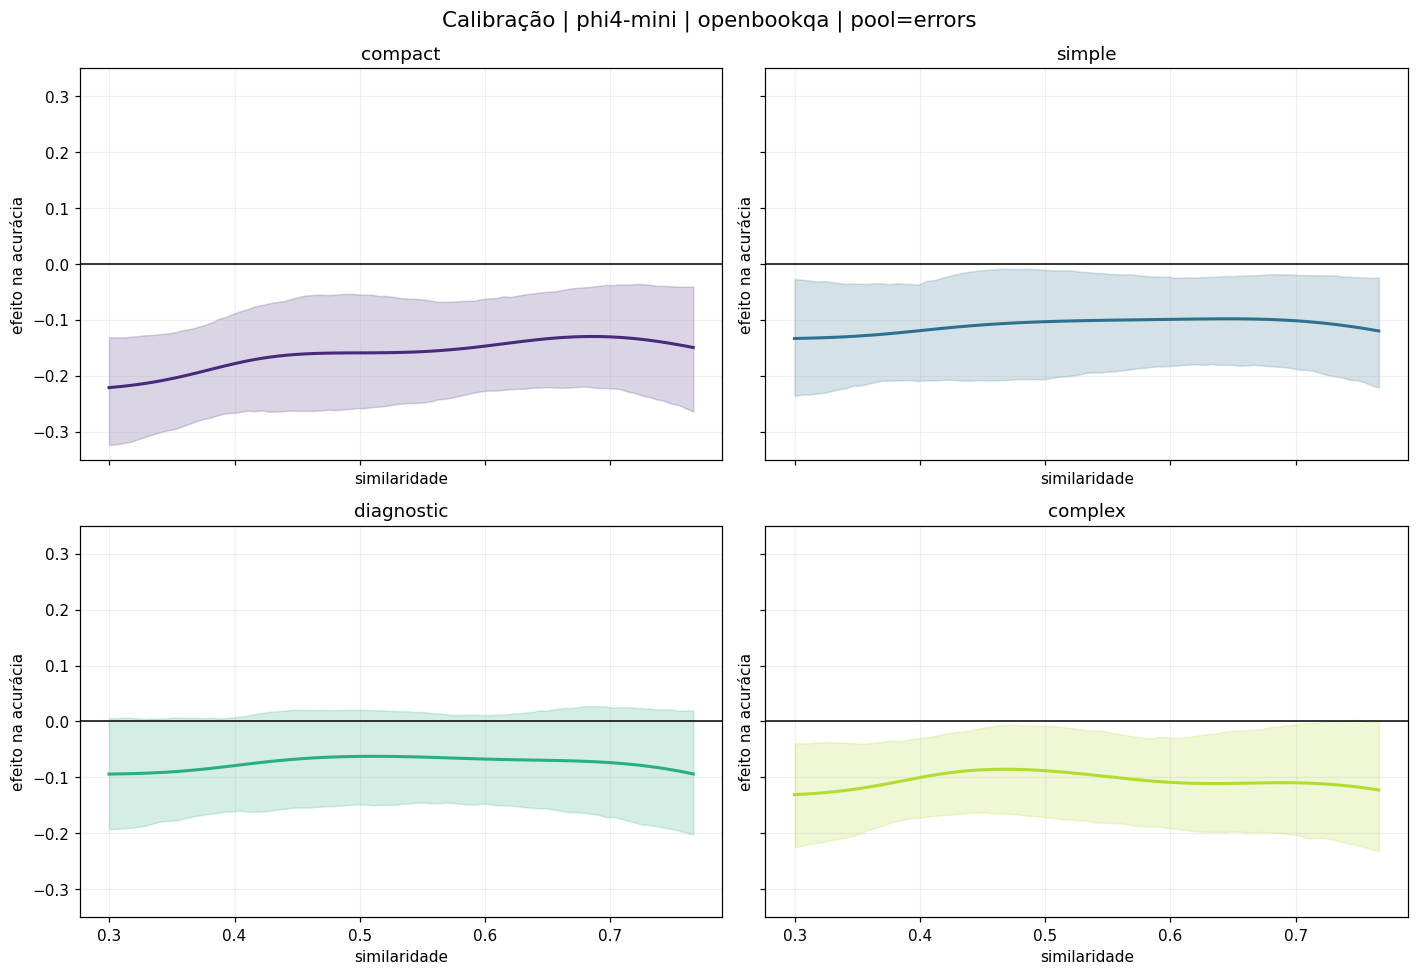

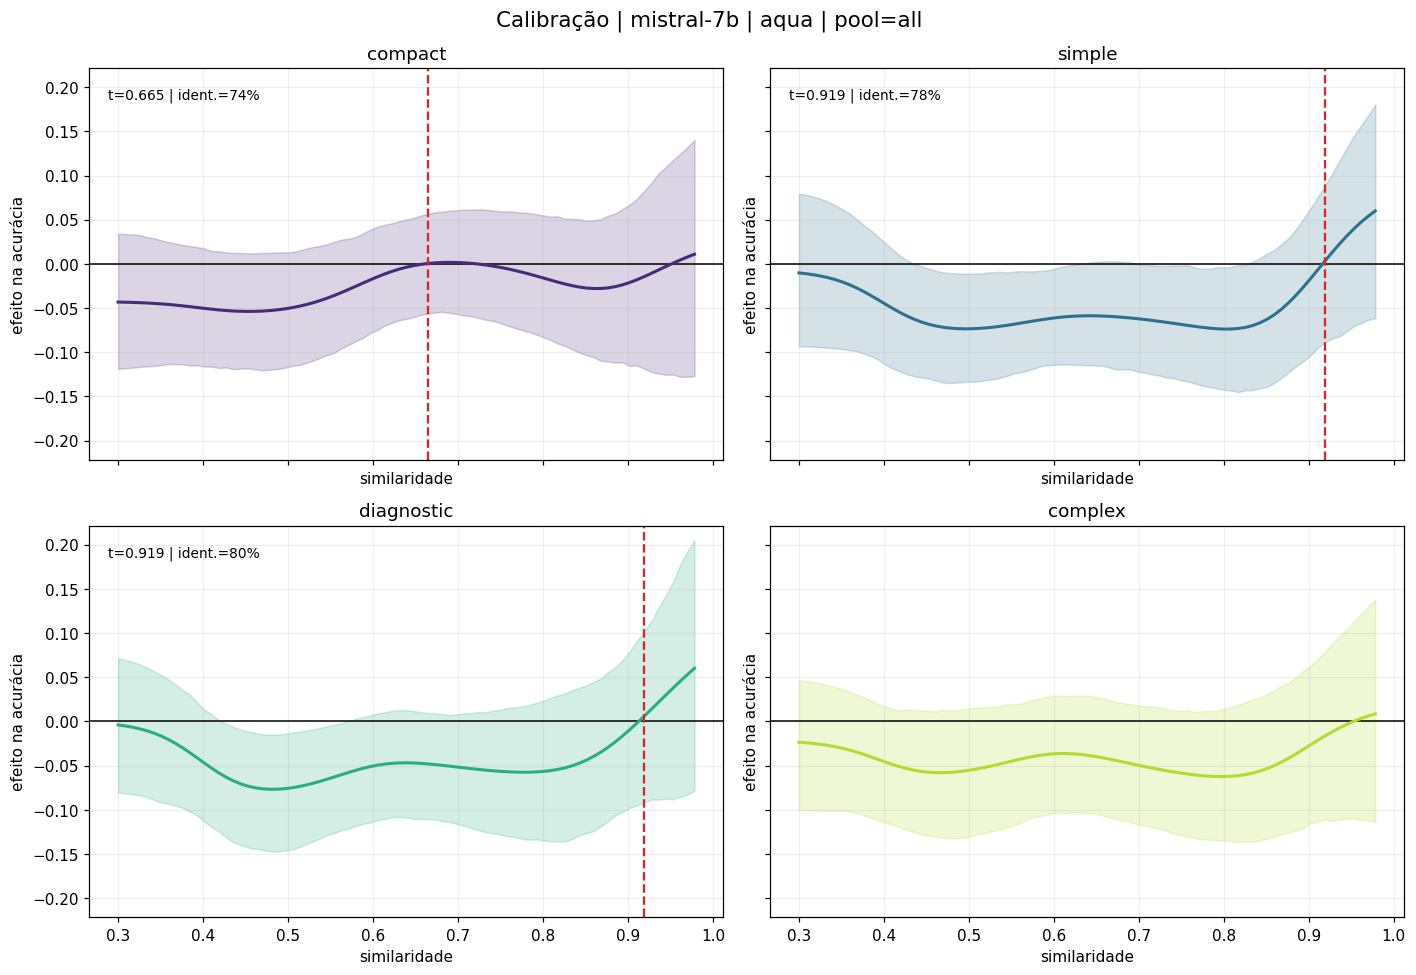

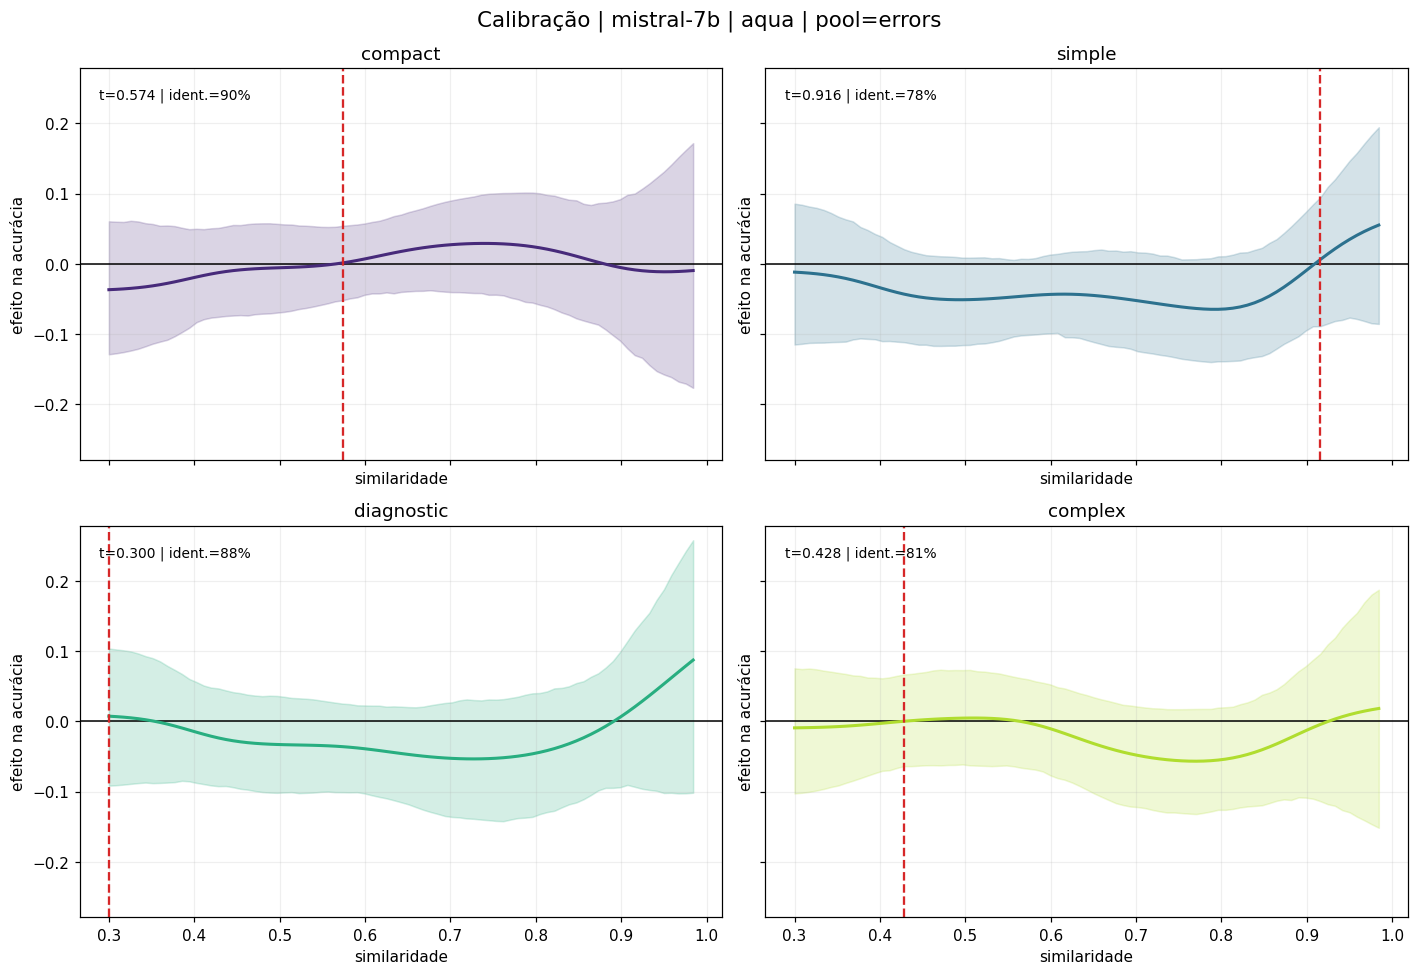

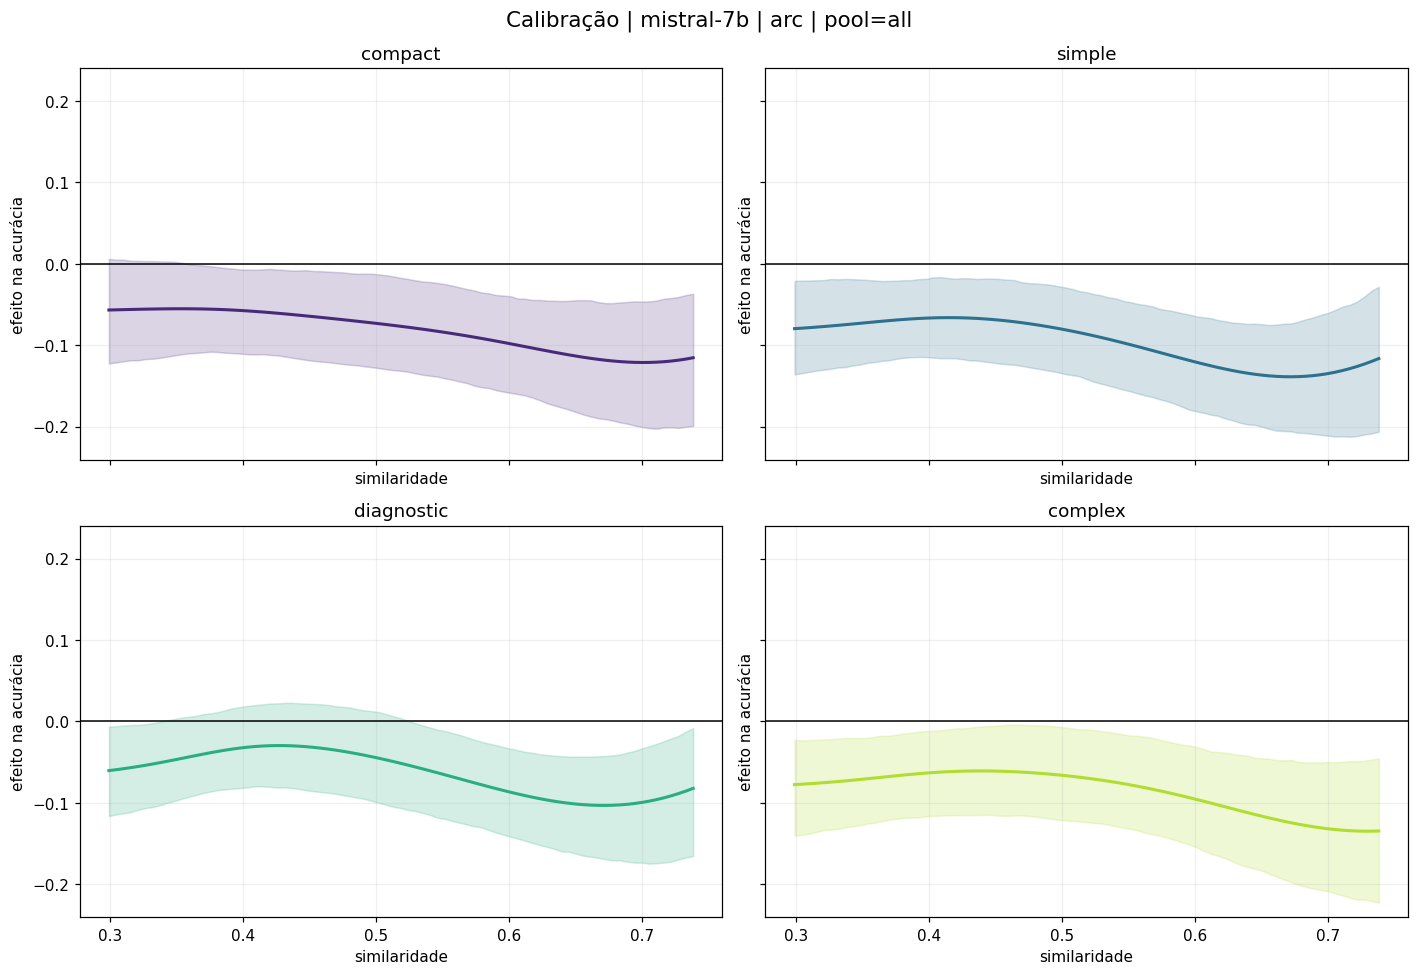

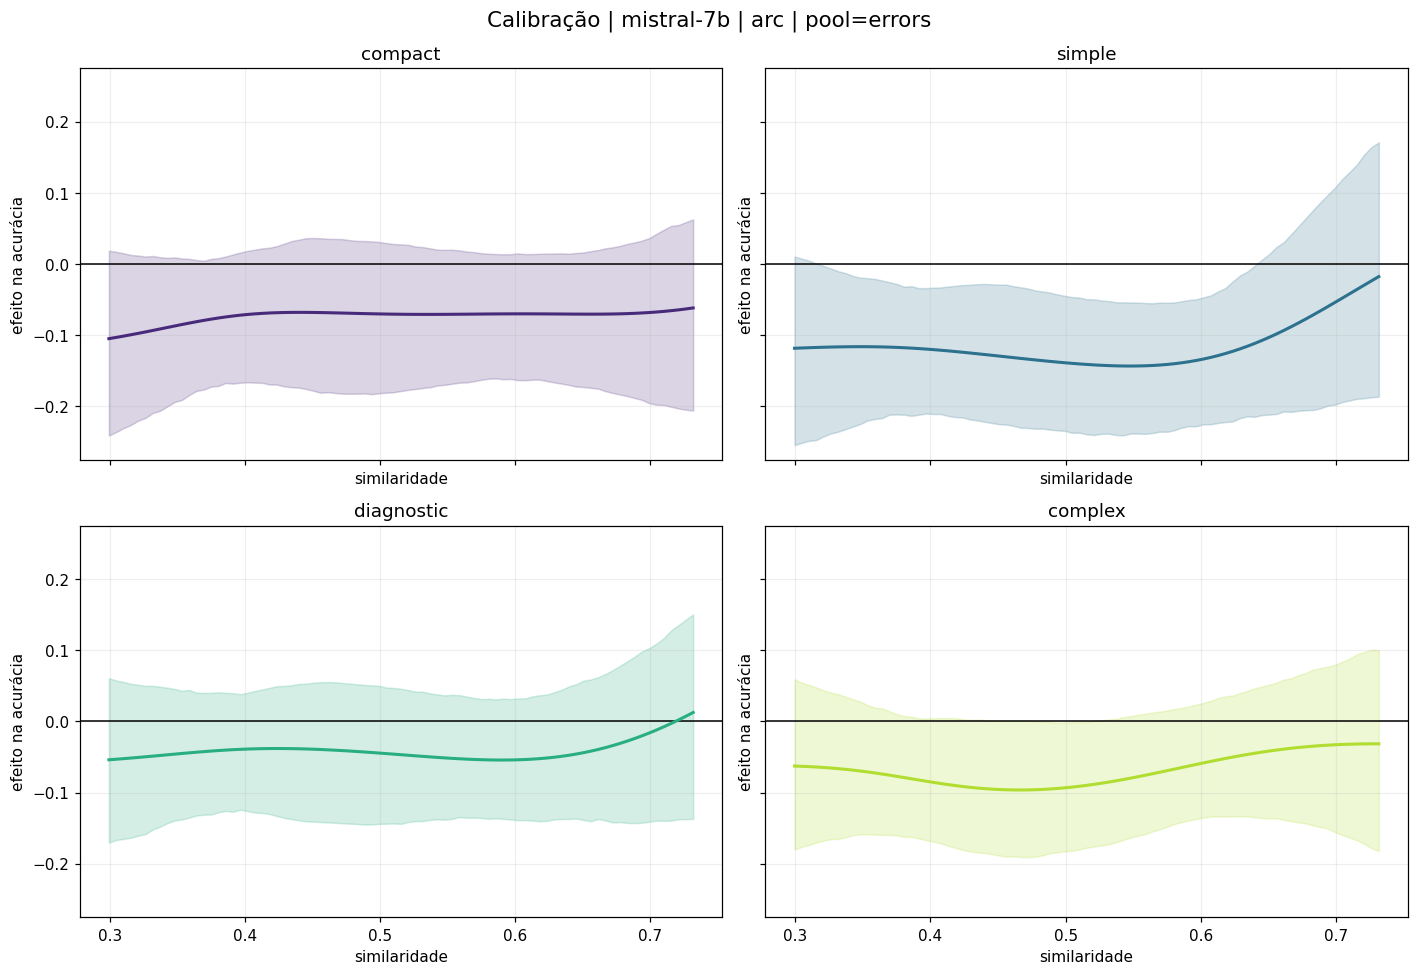

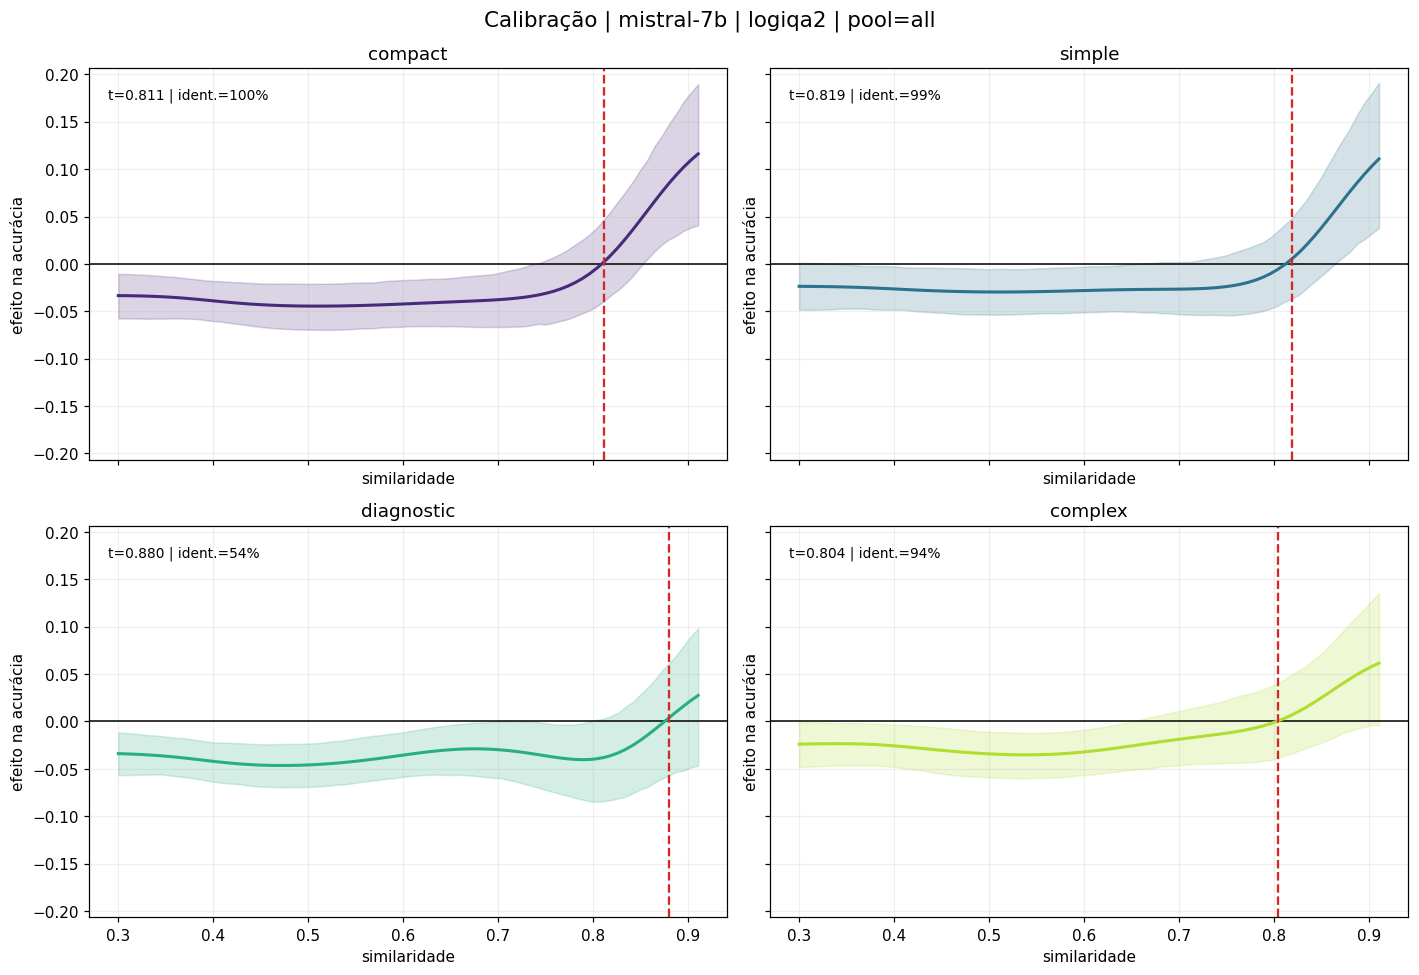

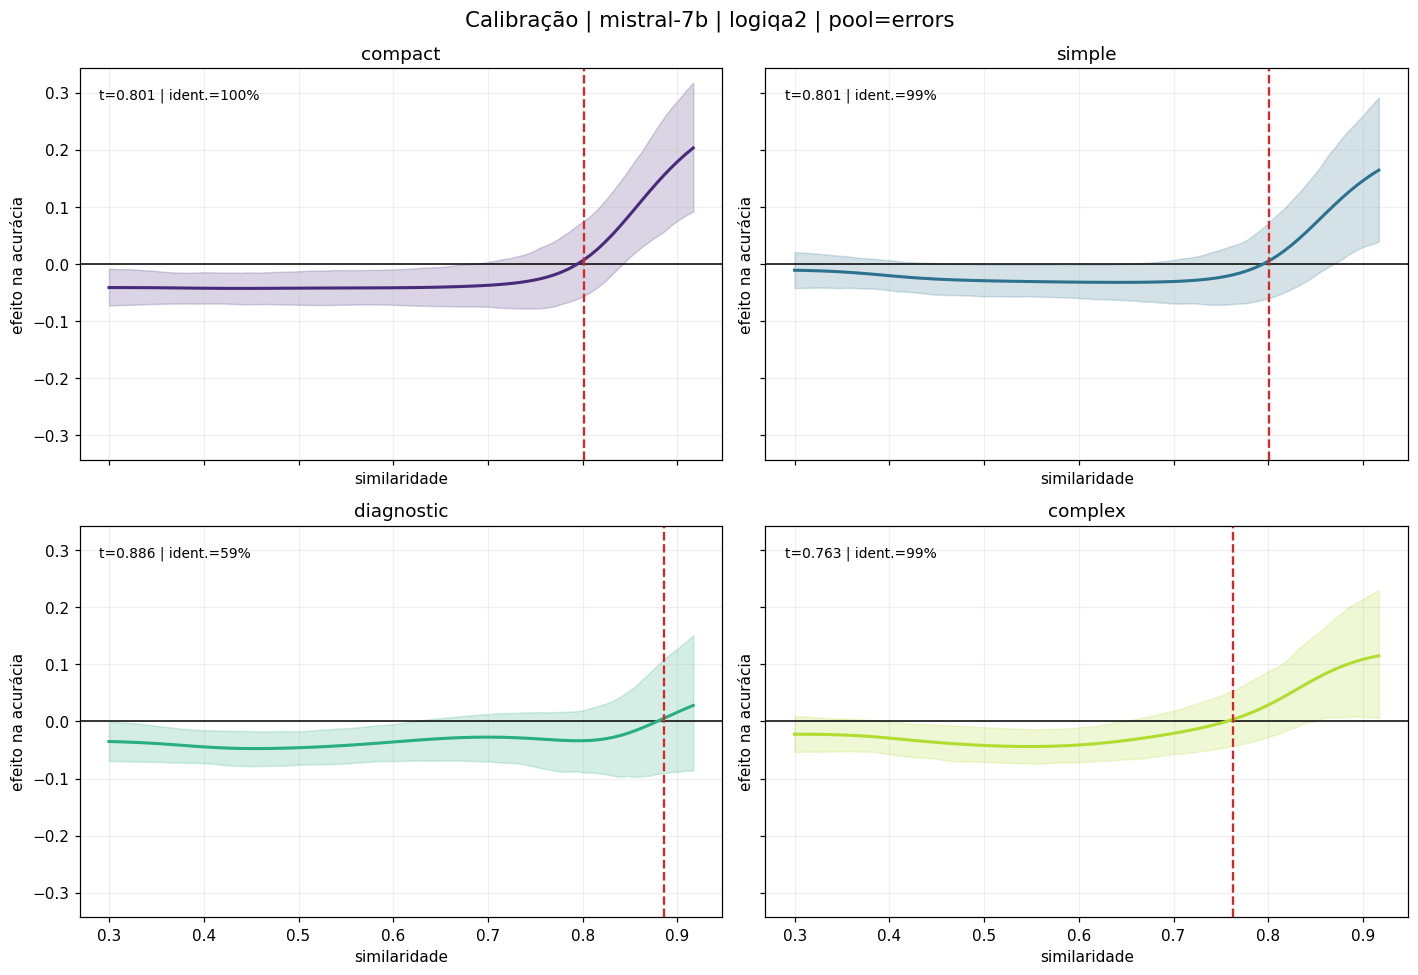

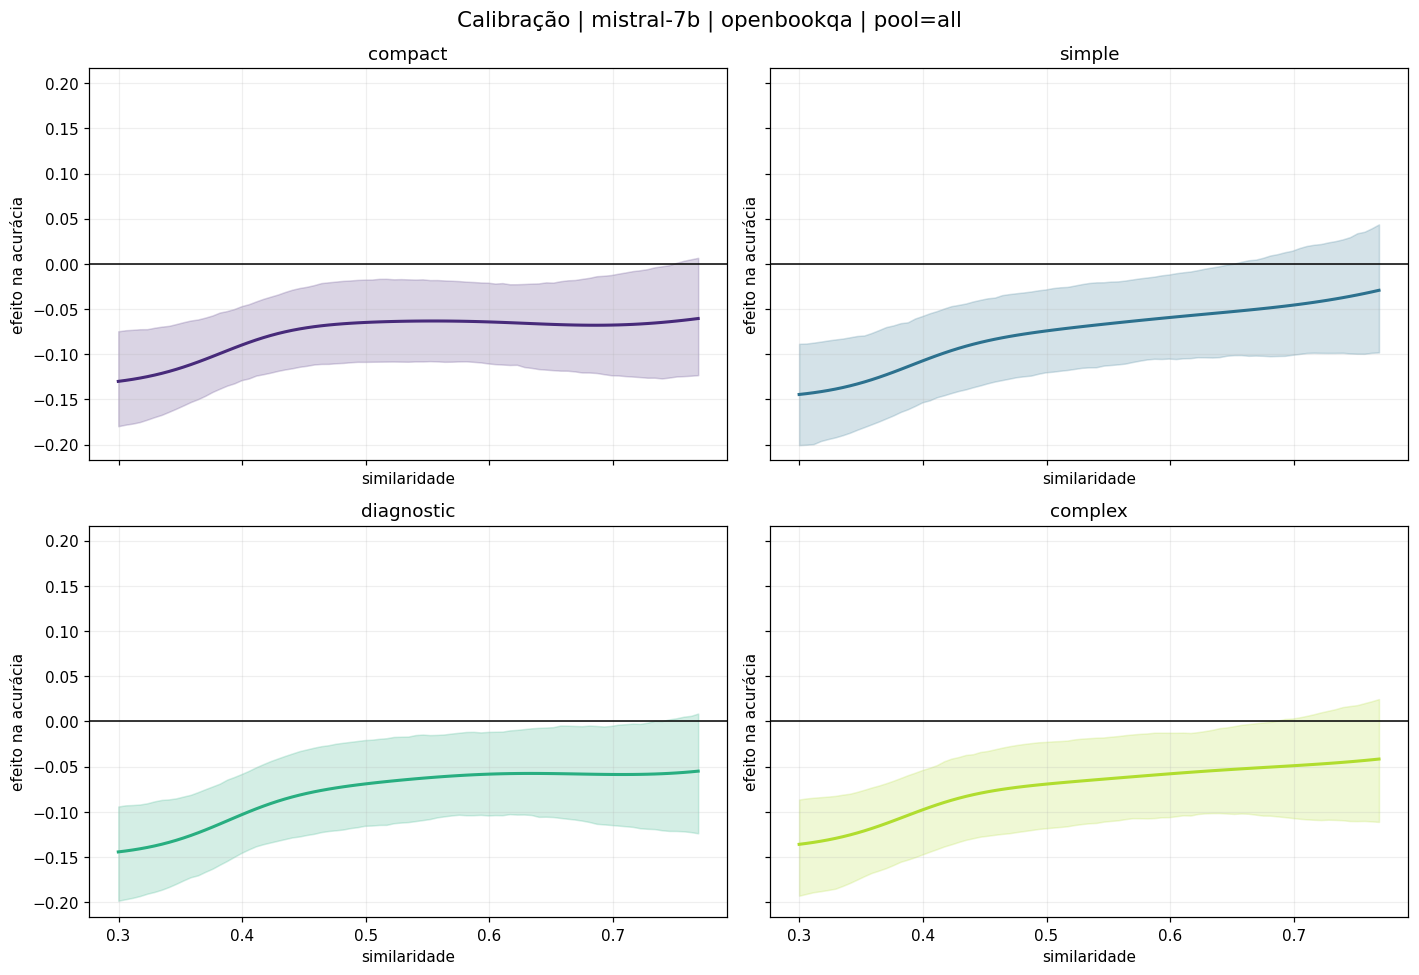

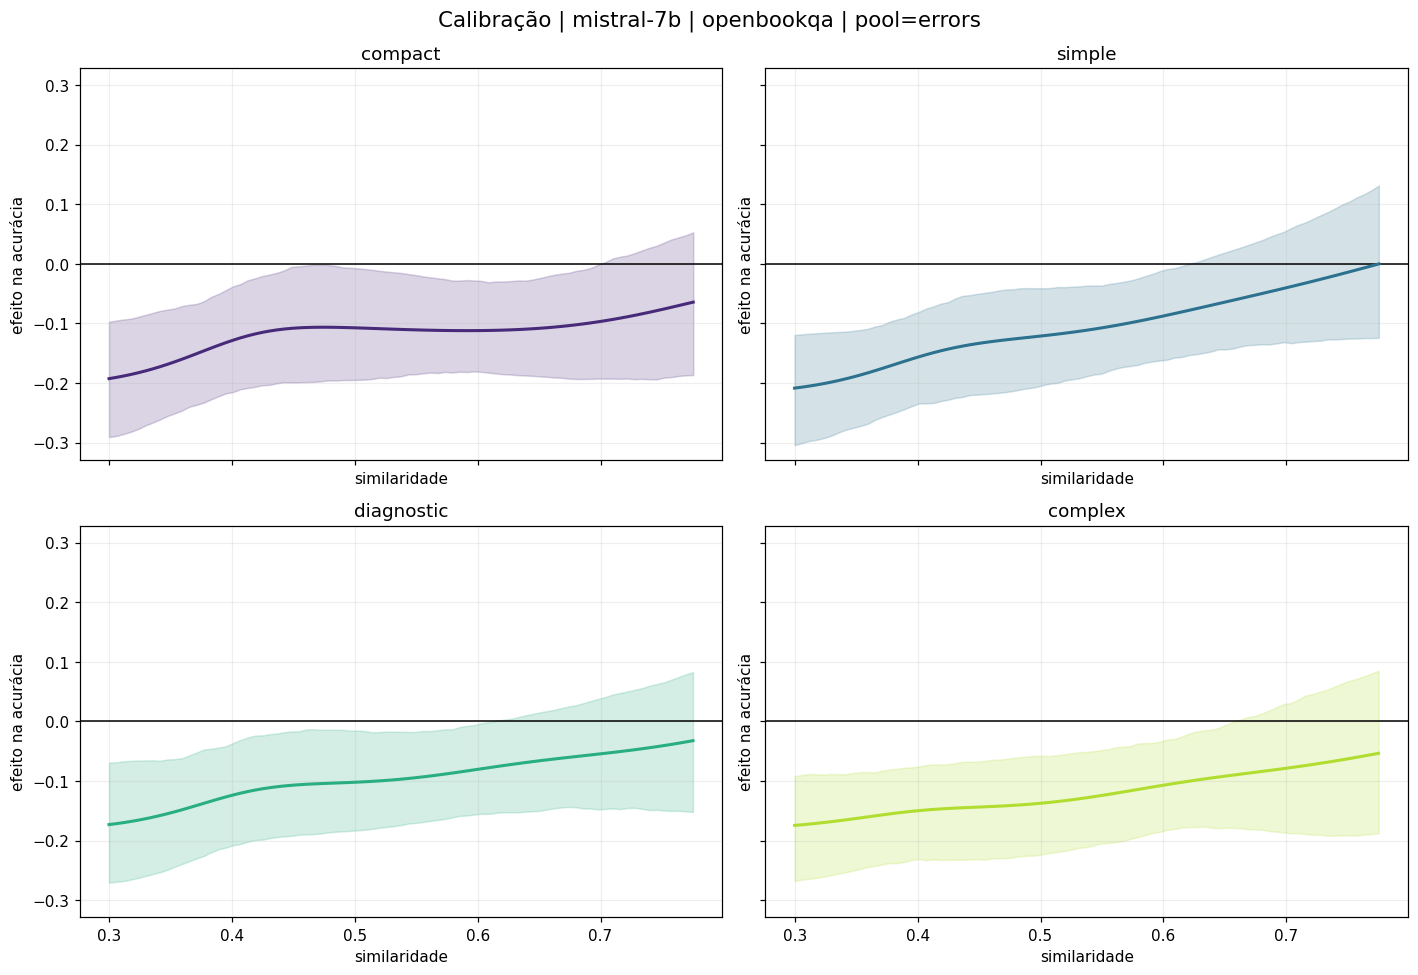

In [5]:
def plot_calibration_dashboard(model, dataset, pool):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
    axes = axes.ravel()
    selected = curves_df[
        (curves_df.model == model) & (curves_df.dataset == dataset)
        & (curves_df.pool == pool) & (curves_df.depth.isin(DEPTH_ORDER))
    ]
    if selected.empty:
        plt.close(fig)
        return
    y_values = selected[["ci_low", "ci_high"]].to_numpy(float)
    finite = y_values[np.isfinite(y_values)]
    y_limit = max(0.05, np.max(np.abs(finite)) * 1.08) if len(finite) else 0.1
    for ax, depth in zip(axes, DEPTH_ORDER):
        curve = selected[selected.depth == depth].sort_values("similarity")
        ax.axhline(0, color="black", lw=1)
        if curve.empty:
            ax.set_title(f"{depth} — sem dados")
            continue
        x = curve.similarity.to_numpy(float)
        effect = curve.effect.to_numpy(float)
        ax.plot(x, effect, color=DEPTH_COLORS[depth], lw=2)
        ax.fill_between(x, curve.ci_low.to_numpy(float), curve.ci_high.to_numpy(float),
                        color=DEPTH_COLORS[depth], alpha=0.20)
        estimate = threshold_df[
            (threshold_df.model == model) & (threshold_df.dataset == dataset)
            & (threshold_df.depth == depth) & (threshold_df.pool == pool)
        ]
        if not estimate.empty and pd.notna(estimate.iloc[0].threshold):
            t = float(estimate.iloc[0].threshold)
            rate = estimate.iloc[0].get("threshold_identification_rate", np.nan)
            ax.axvline(t, color="tab:red", ls="--", lw=1.5)
            ax.text(0.03, 0.95, f"t={t:.3f} | ident.={rate:.0%}", transform=ax.transAxes,
                    va="top", fontsize=9)
        ax.set_title(depth)
        ax.set_ylim(-y_limit, y_limit)
        ax.set_xlabel("similaridade")
        ax.set_ylabel("efeito na acurácia")
    for ax in axes[len(DEPTH_ORDER):]:
        ax.axis("off")
    fig.suptitle(f"Calibração | {model} | {dataset} | pool={pool}", fontsize=14)
    finish(fig, f"02_calibration__{model}__{dataset}__{pool}.png")


for model in MODELS:
    for dataset in DATASETS:
        for pool in COMPARISON_POOLS:
            plot_calibration_dashboard(model, dataset, pool)


## 4. Onde os thresholds aparecem?

Cada célula traz `threshold / taxa de identificação no bootstrap`. O primeiro
número diz **onde** usar a reflexão; o segundo diz quão estável foi encontrar
esse ponto. Células vazias significam que não houve corte sustentado.


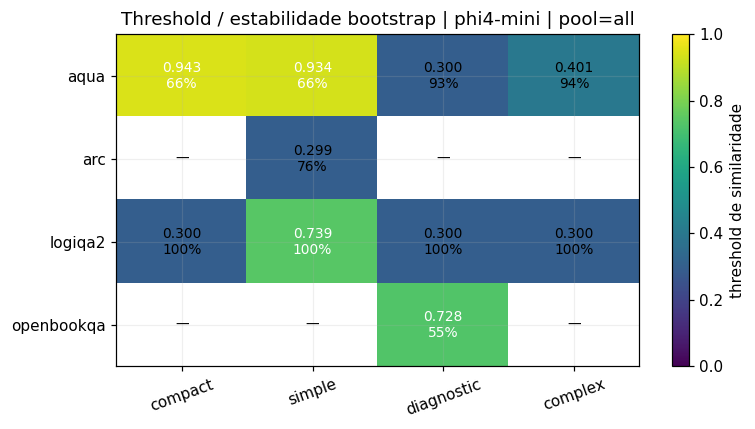

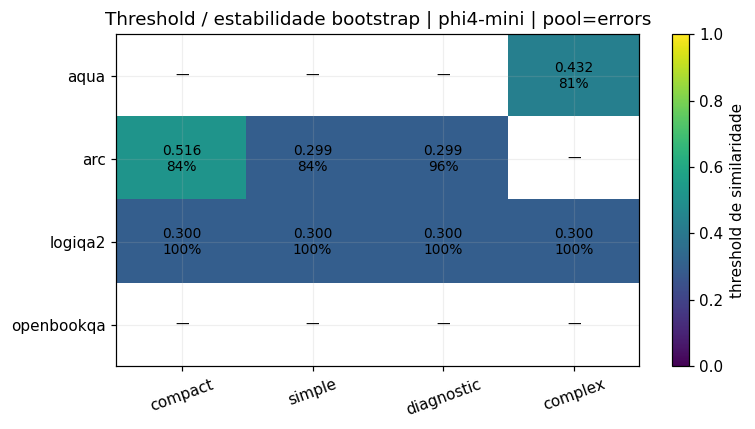

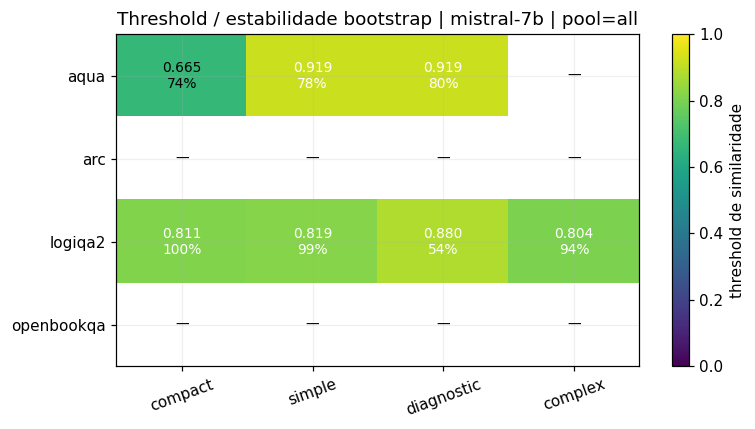

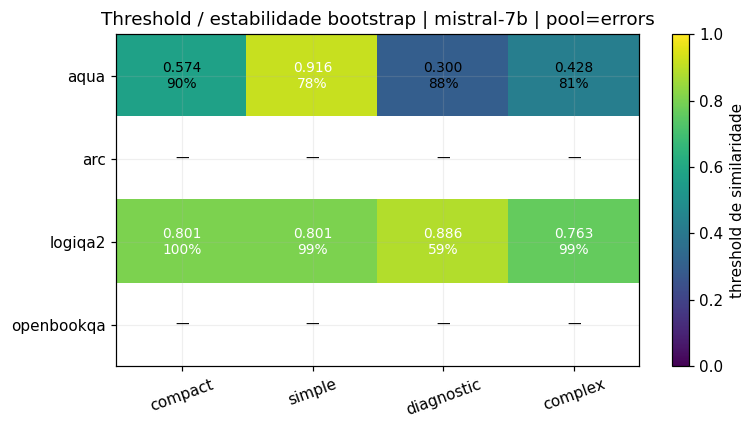

In [6]:
def threshold_heatmap(model, pool):
    sub = threshold_df[(threshold_df.model == model) & (threshold_df.pool == pool)]
    values = sub.pivot(index="dataset", columns="depth", values="threshold").reindex(
        index=DATASETS, columns=DEPTH_ORDER
    )
    rates = sub.pivot(index="dataset", columns="depth", values="threshold_identification_rate").reindex(
        index=DATASETS, columns=DEPTH_ORDER
    )
    fig, ax = plt.subplots(figsize=(max(7, 1.8 * len(DEPTH_ORDER)), max(4, 0.8 * len(DATASETS))))
    masked = np.ma.masked_invalid(values.to_numpy(float))
    image = ax.imshow(masked, cmap="viridis", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(DEPTH_ORDER)), DEPTH_ORDER, rotation=20)
    ax.set_yticks(range(len(DATASETS)), DATASETS)
    for i in range(len(DATASETS)):
        for j in range(len(DEPTH_ORDER)):
            t, rate = values.iloc[i, j], rates.iloc[i, j]
            label = "—" if pd.isna(t) else f"{t:.3f}\n{rate:.0%}"
            color = "white" if pd.notna(t) and (t < 0.28 or t > 0.72) else "black"
            ax.text(j, i, label, ha="center", va="center", color=color, fontsize=9)
    ax.set_title(f"Threshold / estabilidade bootstrap | {model} | pool={pool}")
    fig.colorbar(image, ax=ax, label="threshold de similaridade")
    finish(fig, f"03_threshold_map__{model}__{pool}.png")


for model in MODELS:
    for pool in COMPARISON_POOLS:
        threshold_heatmap(model, pool)


## 5. O threshold generaliza? — efeito no holdout

O forest plot é a evidência principal: usa apenas perguntas que não escolheram
o corte. Pontos à direita ajudam; à esquerda atrapalham. O IC precisa ficar
inteiramente de um lado do zero para uma conclusão confirmatória simples.


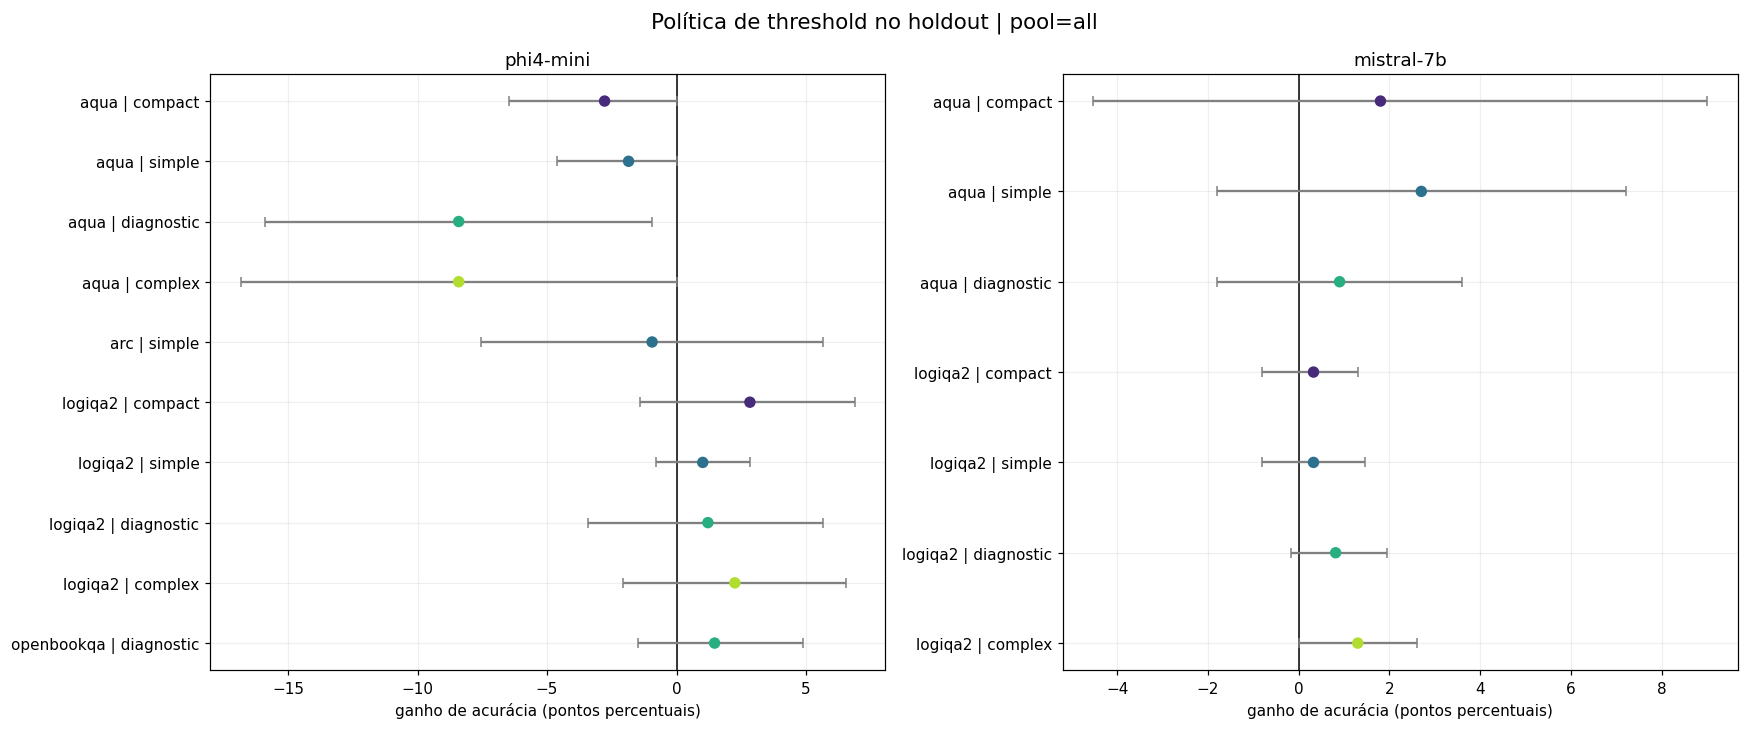

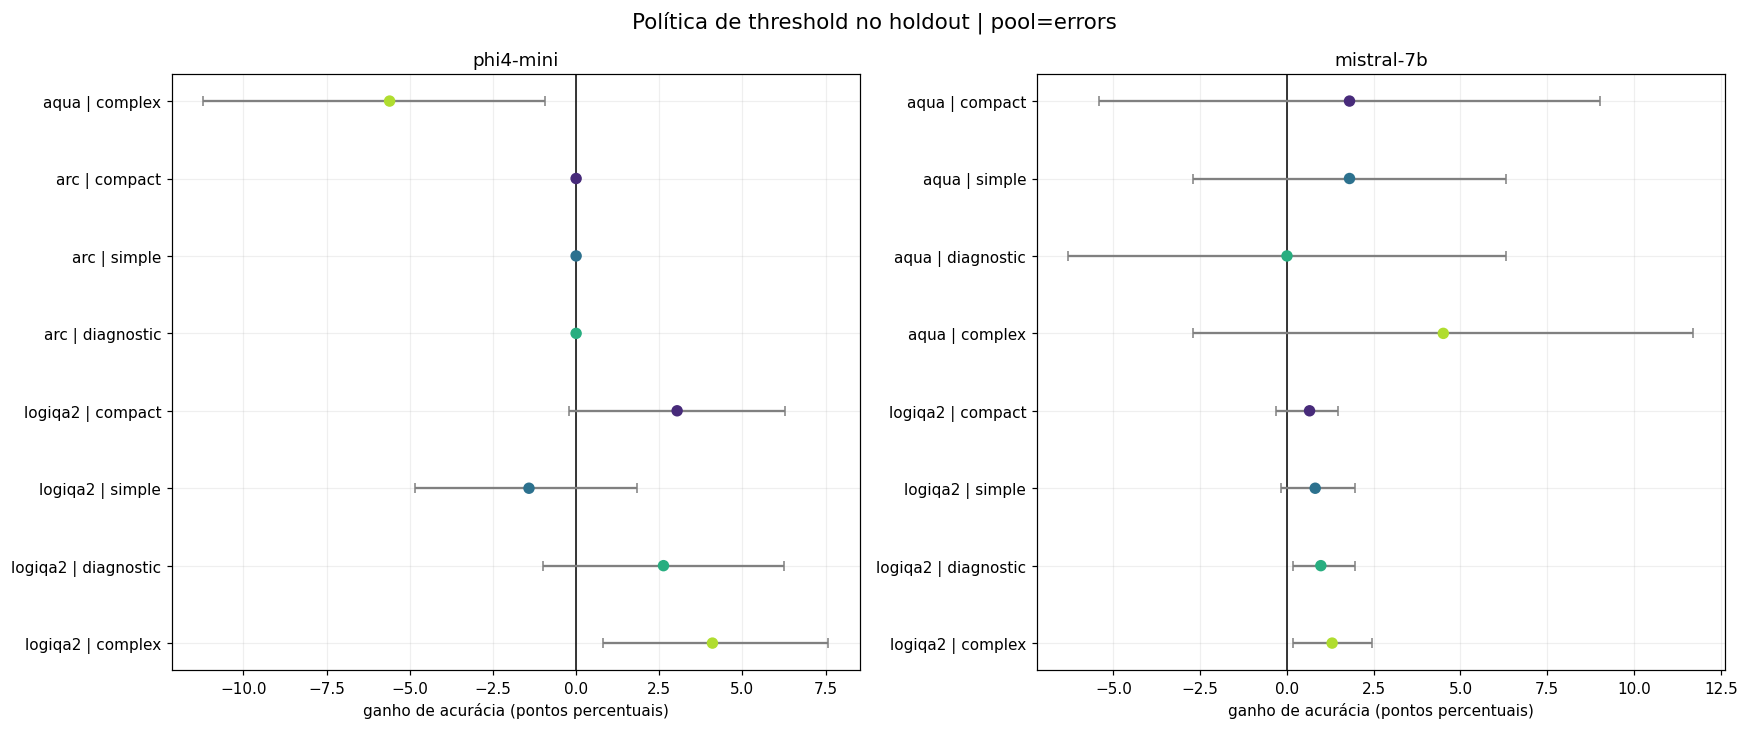

In [7]:
def holdout_forest(pool):
    selected = policy_df[(policy_df.policy == "threshold_top") & (policy_df.pool == pool)].copy()
    if selected.empty:
        print(f"Sem política threshold_top para pool={pool}")
        return
    fig, axes = plt.subplots(1, len(MODELS), figsize=(8 * len(MODELS),
                             max(6, 0.42 * len(DATASETS) * len(DEPTH_ORDER))), squeeze=False)
    for ax, model in zip(axes.ravel(), MODELS):
        sub = selected[selected.model == model].copy()
        sub["dataset"] = pd.Categorical(sub.dataset, DATASETS, ordered=True)
        sub["depth"] = pd.Categorical(sub.depth, DEPTH_ORDER, ordered=True)
        sub = sub.sort_values(["dataset", "depth"])
        y = np.arange(len(sub))
        center = 100 * sub.difference.to_numpy(float)
        low = center - 100 * sub.ci_low.to_numpy(float)
        high = 100 * sub.ci_high.to_numpy(float) - center
        colors = [DEPTH_COLORS[str(d)] for d in sub.depth]
        ax.axvline(0, color="black", lw=1)
        ax.errorbar(center, y, xerr=np.vstack([low, high]), fmt="none", color="gray", capsize=3)
        ax.scatter(center, y, c=colors, s=42, zorder=3)
        ax.set_yticks(y, [f"{r.dataset} | {r.depth}" for r in sub.itertuples()])
        ax.invert_yaxis()
        ax.set_xlabel("ganho de acurácia (pontos percentuais)")
        ax.set_title(model)
    fig.suptitle(f"Política de threshold no holdout | pool={pool}", fontsize=14)
    finish(fig, f"04_holdout_forest__{pool}.png")


for pool in COMPARISON_POOLS:
    holdout_forest(pool)


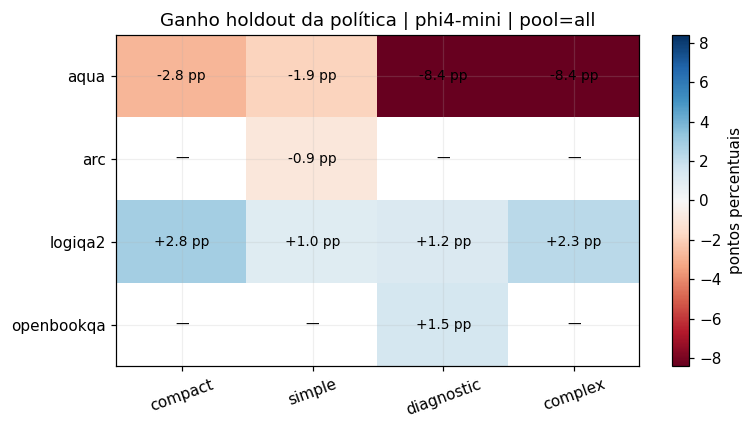

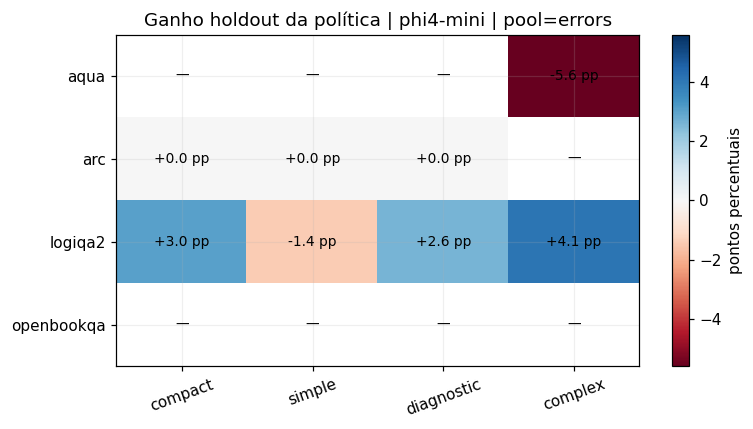

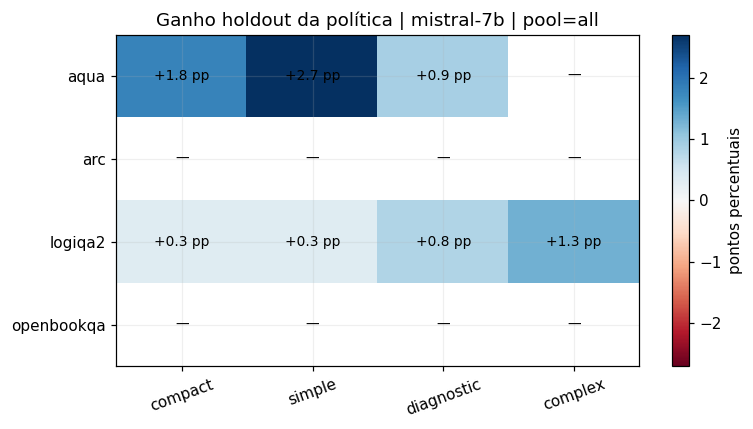

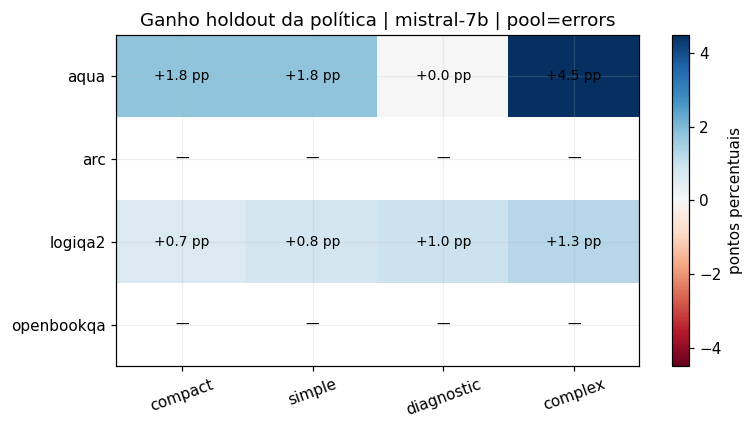

In [8]:
def holdout_heatmap(model, pool):
    sub = policy_df[(policy_df.model == model) & (policy_df.pool == pool)
                    & (policy_df.policy == "threshold_top")]
    values = (100 * sub.pivot(index="dataset", columns="depth", values="difference")).reindex(
        index=DATASETS, columns=DEPTH_ORDER
    )
    if values.empty:
        return
    arr = values.to_numpy(float)
    finite = arr[np.isfinite(arr)]
    limit = max(1, np.max(np.abs(finite))) if len(finite) else 1
    fig, ax = plt.subplots(figsize=(max(7, 1.8 * len(DEPTH_ORDER)), max(4, 0.8 * len(DATASETS))))
    image = ax.imshow(np.ma.masked_invalid(arr), cmap="RdBu", vmin=-limit, vmax=limit, aspect="auto")
    ax.set_xticks(range(len(DEPTH_ORDER)), DEPTH_ORDER, rotation=20)
    ax.set_yticks(range(len(DATASETS)), DATASETS)
    for i in range(len(DATASETS)):
        for j in range(len(DEPTH_ORDER)):
            value = arr[i, j]
            ax.text(j, i, "—" if not np.isfinite(value) else f"{value:+.1f} pp",
                    ha="center", va="center", fontsize=9)
    ax.set_title(f"Ganho holdout da política | {model} | pool={pool}")
    fig.colorbar(image, ax=ax, label="pontos percentuais")
    finish(fig, f"05_holdout_map__{model}__{pool}.png")


for model in MODELS:
    for pool in COMPARISON_POOLS:
        holdout_heatmap(model, pool)


## 6. Threshold versus placebo

Cada ponto compara, na mesma combinação, o efeito da memória selecionada pelo
threshold (eixo vertical) ao efeito do placebo (horizontal). Acima da diagonal,
a recuperação por similaridade foi melhor do que uma memória sem relação.


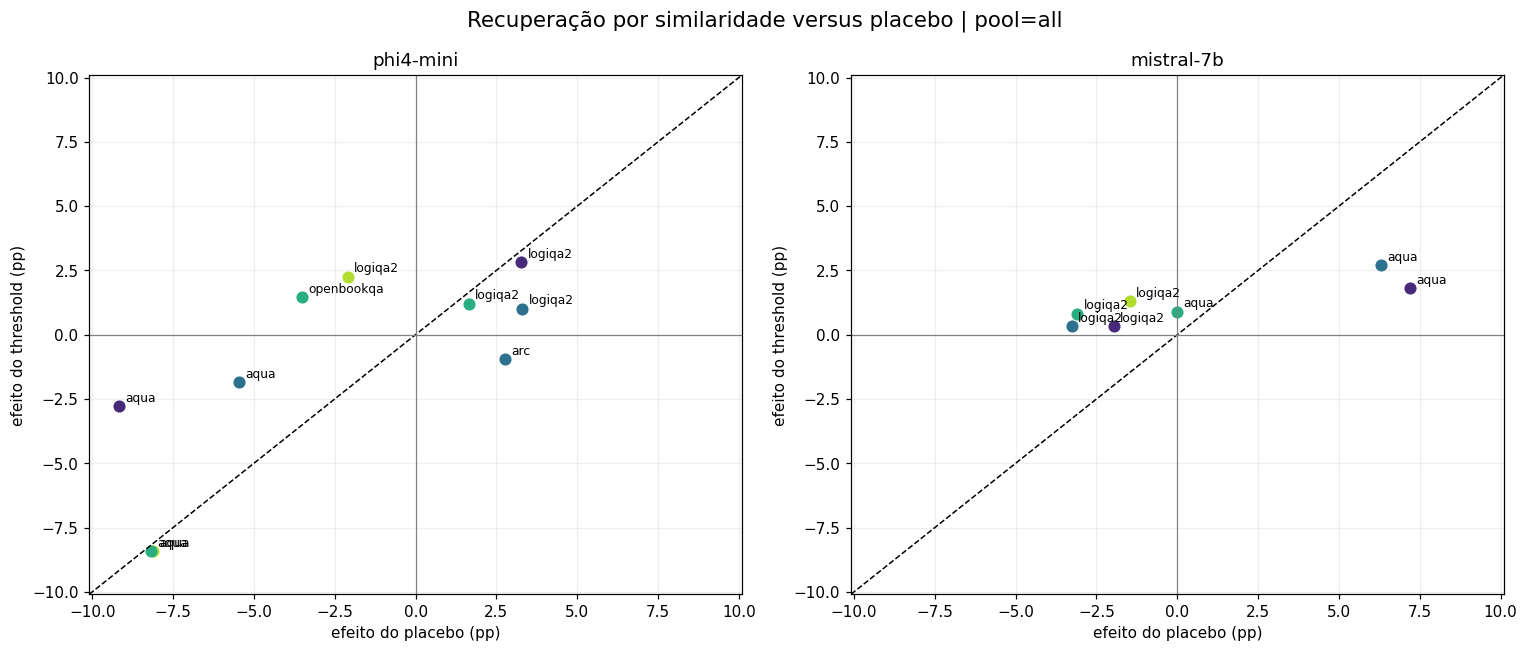

In [9]:
threshold_policy = policy_df[policy_df.policy == "threshold_top"].copy()
placebo_policy = policy_df[policy_df.policy == "placebo"].copy()
join_keys = ["model", "dataset", "depth", "pool"]
comparison = threshold_policy.merge(
    placebo_policy[join_keys + ["difference"]], on=join_keys, how="inner",
    suffixes=("_threshold", "_placebo")
)

for pool in COMPARISON_POOLS:
    sub_pool = comparison[comparison.pool == pool]
    if sub_pool.empty:
        continue
    fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 6), squeeze=False)
    all_values = 100 * sub_pool[["difference_placebo", "difference_threshold"]].to_numpy(float)
    finite = all_values[np.isfinite(all_values)]
    limit = max(3, np.max(np.abs(finite)) * 1.10) if len(finite) else 3
    for ax, model in zip(axes.ravel(), MODELS):
        sub = sub_pool[sub_pool.model == model]
        ax.plot([-limit, limit], [-limit, limit], color="black", ls="--", lw=1)
        ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
        for row in sub.itertuples():
            x, y = 100 * row.difference_placebo, 100 * row.difference_threshold
            ax.scatter(x, y, color=DEPTH_COLORS[row.depth], s=48)
            ax.annotate(row.dataset, (x, y), xytext=(4, 3), textcoords="offset points", fontsize=8)
        ax.set(xlim=(-limit, limit), ylim=(-limit, limit), title=model,
               xlabel="efeito do placebo (pp)", ylabel="efeito do threshold (pp)")
    fig.suptitle(f"Recuperação por similaridade versus placebo | pool={pool}", fontsize=14)
    finish(fig, f"06_threshold_vs_placebo__{pool}.png")


## 7. Como a reflexão ajuda ou atrapalha

O eixo vertical é a fração de respostas corrigidas; o horizontal é a fração de
respostas corretas que foram estragadas. Acima da diagonal há saldo positivo.
O tamanho do ponto representa quantas perguntas receberam memória.


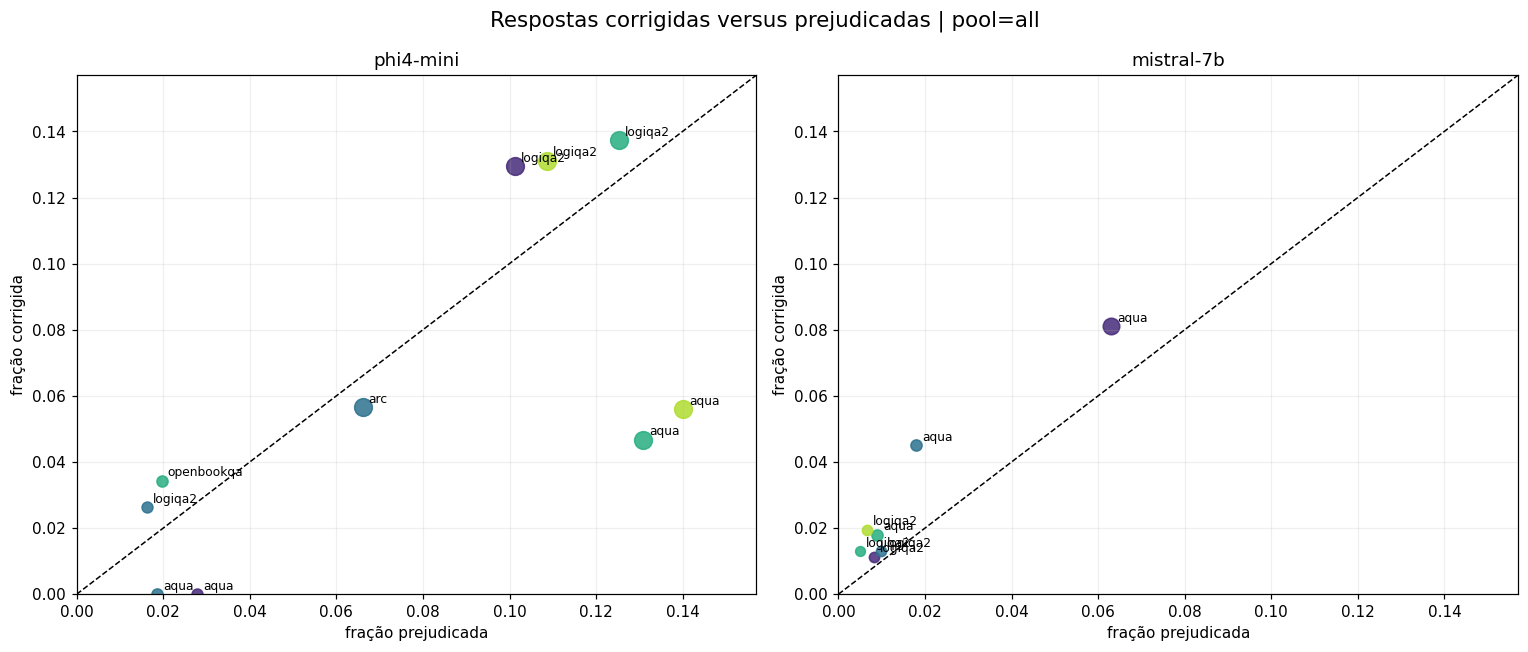

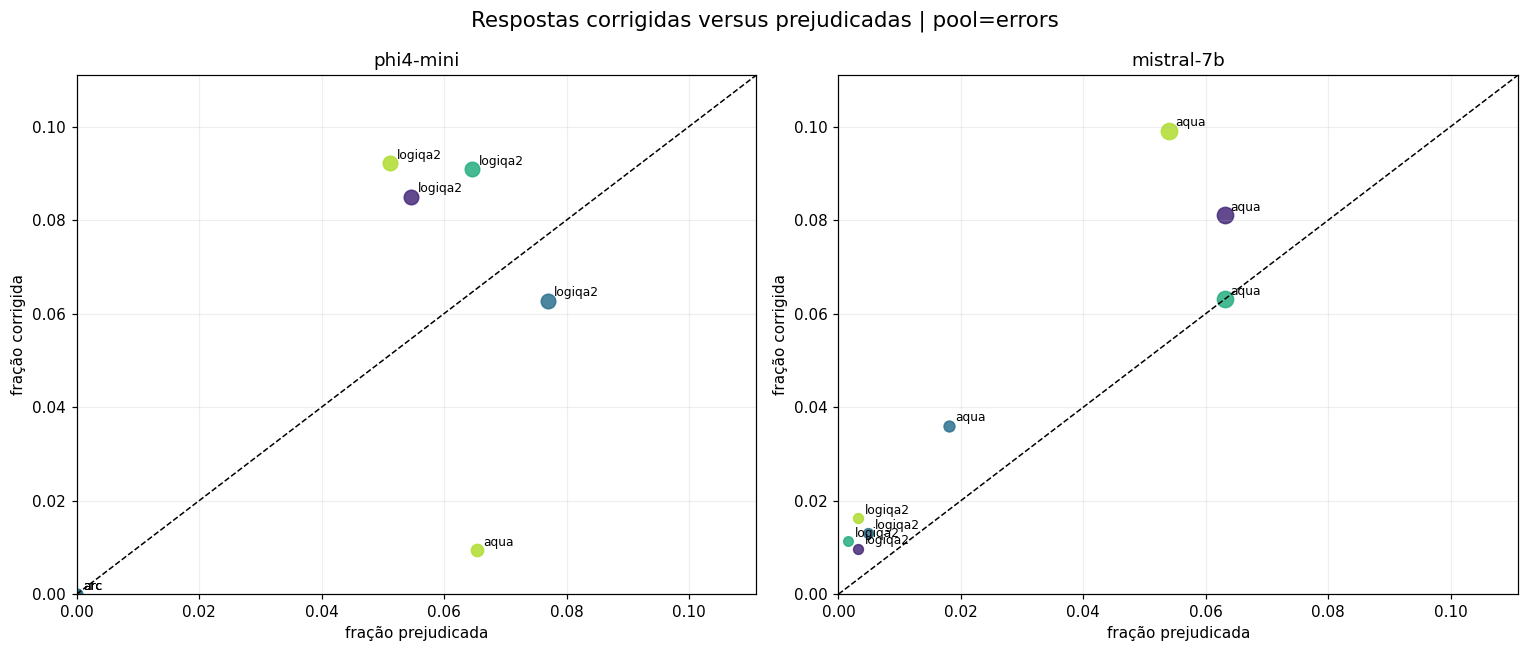

In [10]:
selected = policy_df[policy_df.policy == "threshold_top"].copy()
selected["helped_rate"] = selected.helped / selected.n
selected["harmed_rate"] = selected.harmed / selected.n

for pool in COMPARISON_POOLS:
    sub_pool = selected[selected.pool == pool]
    if sub_pool.empty:
        continue
    fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 6), squeeze=False)
    limit = max(0.01, sub_pool[["helped_rate", "harmed_rate"]].max().max() * 1.12)
    for ax, model in zip(axes.ravel(), MODELS):
        sub = sub_pool[sub_pool.model == model]
        ax.plot([0, limit], [0, limit], color="black", ls="--", lw=1)
        for row in sub.itertuples():
            size = 35 + 100 * float(getattr(row, "memory_use_rate", 0) or 0)
            ax.scatter(row.harmed_rate, row.helped_rate, color=DEPTH_COLORS[row.depth], s=size, alpha=0.85)
            ax.annotate(row.dataset, (row.harmed_rate, row.helped_rate),
                        xytext=(4, 3), textcoords="offset points", fontsize=8)
        ax.set(xlim=(0, limit), ylim=(0, limit), title=model,
               xlabel="fração prejudicada", ylabel="fração corrigida")
    fig.suptitle(f"Respostas corrigidas versus prejudicadas | pool={pool}", fontsize=14)
    finish(fig, f"07_helped_vs_harmed__{pool}.png")


## 8. Tabela final com controle de comparações múltiplas

Como há vários modelos, datasets e reflexões, também reportamos `q_bh`, o
p-valor de McNemar corrigido por Benjamini–Hochberg dentro de cada pool. A
ordenação prioriza efeito holdout, mas a interpretação deve combinar IC 95%,
`q_bh`, estabilidade do threshold e comparação com placebo.


In [11]:
def bh_adjust(values):
    values = np.asarray(values, dtype=float)
    result = np.full(len(values), np.nan)
    valid = np.flatnonzero(np.isfinite(values))
    if not len(valid):
        return result
    order = valid[np.argsort(values[valid])]
    ranked = values[order] * len(order) / np.arange(1, len(order) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    result[order] = np.minimum(ranked, 1.0)
    return result


ranking = policy_df[policy_df.policy == "threshold_top"].copy()
ranking["q_bh"] = ranking.groupby("pool")["mcnemar_p"].transform(bh_adjust)
ranking["effect_pp"] = 100 * ranking.difference
ranking["ci_low_pp"] = 100 * ranking.ci_low
ranking["ci_high_pp"] = 100 * ranking.ci_high
ranking["conclusion"] = np.select(
    [ranking.ci_low > 0, ranking.ci_high < 0],
    ["benefício", "dano"], default="inconclusivo"
)
columns = [
    "model", "dataset", "depth", "pool", "threshold", "memory_use_rate",
    "effect_pp", "ci_low_pp", "ci_high_pp", "mcnemar_p", "q_bh", "conclusion",
]
display(ranking.sort_values(["pool", "effect_pp"], ascending=[True, False])[columns])

for pool in COMPARISON_POOLS:
    sub = ranking[ranking.pool == pool]
    benefit = sub[sub.ci_low > 0].sort_values("difference", ascending=False)
    harm = sub[sub.ci_high < 0].sort_values("difference")
    print(f"\nPOOL={pool}")
    print("Benefícios com IC 95% acima de zero:", len(benefit))
    for row in benefit.itertuples():
        print(f"- {row.model}/{row.dataset}/{row.depth}: {100*row.difference:+.1f} pp; "
              f"IC [{100*row.ci_low:+.1f}, {100*row.ci_high:+.1f}]; q={row.q_bh:.3g}")
    print("Danos com IC 95% abaixo de zero:", len(harm))
    for row in harm.itertuples():
        print(f"- {row.model}/{row.dataset}/{row.depth}: {100*row.difference:+.1f} pp; "
              f"IC [{100*row.ci_low:+.1f}, {100*row.ci_high:+.1f}]; q={row.q_bh:.3g}")

if not quality_df.empty:
    high_truncation = quality_df[quality_df.truncation_rate > 0.10]
    print("\nReflexões com mais de 10% de truncamento:")
    if high_truncation.empty:
        print("- Nenhuma.")
    else:
        for row in high_truncation.itertuples():
            print(f"- {row.model}/{row.depth}: {row.truncation_rate:.1%}")

print("\nPlots salvos em:", short_path(PLOT_DIR))


,model,dataset,depth,pool,threshold,memory_use_rate,effect_pp,ci_low_pp,ci_high_pp,mcnemar_p,q_bh,conclusion
127,phi4-mini,logiqa2,compact,all,0.299898,1.000000,2.834008,-1.417004,6.882591,0.223230,0.708333,inconclusivo
18,mistral-7b,aqua,simple,all,0.918840,0.189189,2.702703,-1.801802,7.207207,0.453125,0.848189,inconclusivo
134,phi4-mini,logiqa2,complex,all,0.299903,1.000000,2.254098,-2.049180,6.557377,0.355280,0.814534,inconclusivo
1,mistral-7b,aqua,compact,all,0.664521,0.819820,1.801802,-4.527027,9.009009,0.803619,0.910769,inconclusivo
164,phi4-mini,openbookqa,diagnostic,all,0.727946,0.181373,1.470588,-1.470588,4.901961,0.548828,0.848189,inconclusivo
47,mistral-7b,logiqa2,complex,all,0.803631,0.104065,1.300813,0.000000,2.601626,0.076813,0.444005,inconclusivo
141,phi4-mini,logiqa2,diagnostic,all,0.299901,1.000000,1.212121,-3.434343,5.656566,0.661170,0.910769,inconclusivo
148,phi4-mini,logiqa2,simple,all,0.738686,0.159919,1.012146,-0.809717,2.834008,0.383310,0.814534,inconclusivo
12,mistral-7b,aqua,diagnostic,all,0.918840,0.189189,0.900901,-1.801802,3.603604,1.000000,1.000000,inconclusivo
53,mistral-7b,logiqa2,diagnostic,all,0.879954,0.060163,0.813008,-0.162602,1.951220,0.226562,0.708333,inconclusivo



POOL=all
Benefícios com IC 95% acima de zero: 0
Danos com IC 95% abaixo de zero: 1
- phi4-mini/aqua/diagnostic: -8.4 pp; IC [-15.9, -0.9]; q=0.444

POOL=errors
Benefícios com IC 95% acima de zero: 3
- phi4-mini/logiqa2/complex: +4.1 pp; IC [+0.8, +7.6]; q=0.281
- mistral-7b/logiqa2/complex: +1.3 pp; IC [+0.2, +2.4]; q=0.281
- mistral-7b/logiqa2/diagnostic: +1.0 pp; IC [+0.2, +2.0]; q=0.281
Danos com IC 95% abaixo de zero: 1
- phi4-mini/aqua/complex: -5.6 pp; IC [-11.2, -0.9]; q=0.281

Reflexões com mais de 10% de truncamento:
- mistral-7b/compact: 13.6%
- mistral-7b/simple: 24.7%
- mistral-7b/diagnostic: 28.5%
- mistral-7b/complex: 33.2%

Plots salvos em: data/results/similarity_threshold_v2/3f47a5b014cd/plots_comparison_v2
